# Artificial Neural Networks and Deep Learning



---




# ⚙️ Install required dependencies

In this case, we utilized `keras-cv` a powerful library designed to support computer vision tasks such as data augmentation, classification, object detection, and segmentation. For this challenge, we primarily used this library to apply advanced augmentations to our training data, enhancing the model's ability to generalize effectively to new image sets.

In [1]:
%%capture

!pip uninstall -y tensorflow keras tensorflow-addons vit-keras keras-cv



In [2]:
!pip install keras-cv


!pip install pynrrd

  Using cached keras_cv-0.9.0-py3-none-any.whl.metadata (12 kB)
Using cached keras_cv-0.9.0-py3-none-any.whl (650 kB)


In [3]:
!pip install tensorflow

  Using cached tensorflow-2.18.0-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (4.1 kB)
  Using cached keras-3.8.0-py3-none-any.whl.metadata (5.8 kB)
Using cached tensorflow-2.18.0-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (615.3 MB)
Using cached keras-3.8.0-py3-none-any.whl (1.3 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-decision-forests 1.10.0 requires tensorflow==2.17.0, but you have tensorflow 2.18.0 which is incompatible.
tensorflow-text 2.17.0 requires tensorflow<2.18,>=2.17.0, but you have tensorflow 2.18.0 which is incompatible.
tf-keras 2.17.0 requires tensorflow<2.18,>=2.17, but you have tensorflow 2.18.0 which is incompatible.


In [4]:
import tensorflow as tf

print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available: 2


In [5]:
print(tf.config.list_physical_devices('GPU'))


[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [6]:


print("TensorFlow rileva GPU:", tf.config.list_physical_devices('GPU'))



TensorFlow rileva GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [7]:
!nvidia-smi


Fri Feb  7 11:48:09 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 560.35.03              Driver Version: 560.35.03      CUDA Version: 12.6     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P8             10W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [8]:
!echo $PATH | grep cuda


~/.local/bin:/opt/bin:/usr/local/nvidia/bin:/usr/local/cuda/bin:/usr/local/sbin:/usr/local/bin:/usr/sbin:/usr/bin:/sbin:/bin:/tools/node/bin:/tools/google-cloud-sdk/bin


In [9]:
from tensorflow.python.client import device_lib
print(device_lib.list_local_devices())


[name: "/device:CPU:0"
device_type: "CPU"
memory_limit: 268435456
locality {
}
incarnation: 202444984325172318
xla_global_id: -1
, name: "/device:GPU:0"
device_type: "GPU"
memory_limit: 14619377664
locality {
  bus_id: 1
  links {
  }
}
incarnation: 11832795546232000307
physical_device_desc: "device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5"
xla_global_id: 416903419
, name: "/device:GPU:1"
device_type: "GPU"
memory_limit: 14619377664
locality {
  bus_id: 1
  links {
  }
}
incarnation: 14516055691844474931
physical_device_desc: "device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5"
xla_global_id: 2144165316
]


In [10]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.device_count())
print(torch.cuda.get_device_name(0))


True
2
Tesla T4


# ⚙️ Import libraries

In [11]:

import tensorflow as tf
from tensorflow import keras as tfk
import keras
from keras import layers as tfkl

print("TensorFlow version:", tf.__version__)
print("Keras version:", keras.__version__)



TensorFlow version: 2.18.0
Keras version: 3.8.0


In [12]:
import os

import logging
import numpy as np

import cv2

# Plot libraries
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix

# Suppress warnings
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=Warning)


# Reduce TensorFlow verbosity
tf.autograph.set_verbosity(0)
tf.get_logger().setLevel(logging.ERROR)
tf.compat.v1.logging.set_verbosity(tf.compat.v1.logging.ERROR)

RANDOM_SEED = 200723
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED);

# 🧙 Auxiliary functions

#### Helper functions to identify and remove all the outliers

In [13]:
def check_overlay(image, template, threshold=0.99):
  """
    Checks if a given template matches a portion of the input image within a specified threshold.

    This function uses the OpenCV method `cv2.matchTemplate` to slide the template image over
    the input image (as in 2D convolution) and compares the template and the image patch
    under the template to compute a similarity score. If the maximum similarity score exceeds
    the provided threshold, the function returns True, indicating a match.

  """

  image_gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
  result = cv2.matchTemplate(image_gray, template, cv2.TM_CCOEFF_NORMED)
  _, max_val, _, max_loc = cv2.minMaxLoc(result)

  return max_val >= threshold

---

#### Plot random images for each label

In [14]:
# Plot a random image for each label
def plot_images(rows, images, labels):
  """
  Plots n_samples images for each label in a grid.

  Each row represents a different sample, and each column represents a different label.
  """

  unique_labels = np.unique(labels)
  cols = len(unique_labels) * 2

  plt.figure(figsize=(15, 5))


  # Iterate through samples and labels
  for i in range(rows):
      for j, label in enumerate(unique_labels):
          # Find an image with the current label
          label_indices = np.where(labels == label)[0]
          random_index = np.random.choice(label_indices, size=1)[0]

          # Calculate the subplot index for original image
          subplot_index_original = i * cols + j * 2 + 1

          # Plot the original image
          plt.subplot(rows, cols, subplot_index_original)
          plt.imshow(images[random_index], cmap="gray")
          plt.axis('off')

          # Add title only to the first row
          if i == 0:
              plt.title(f"Label: {label}", pad=10, fontsize=12)

  plt.tight_layout()
  plt.show()

#### Plot the labels distribution highlighting the split in "Training" and "Validation + Test"

In [15]:
def plot_labels_distribution(y_train, y_val, y_test):
  # Combine the labels from all three sets into one list to plot their distributions
  sets = ['Training', 'Validation + Test']
  y_test_val = np.concatenate([y_test, y_val])

  labels_sets = [y_train, y_test_val]

  # Create a figure to plot
  plt.figure(figsize=(12, 6))

  # Plot the class distributions for each set
  for i, labels in enumerate(labels_sets):
    # Calculate class distribution
    unique, counts = np.unique(labels, return_counts=True)
    distribution = dict(zip(unique, counts))

    # Plot each distribution with a different color
    sns.barplot(x=list(distribution.keys()), y=list(distribution.values()), label=sets[i], alpha=0.7)

  # Customize plot
  plt.title('Class Distribution in Training, Validation, and Test Sets', fontsize=16)
  plt.xlabel('Class Labels', fontsize=12)
  plt.ylabel('Number of Samples', fontsize=12)
  plt.legend(title='Data Set', loc='upper right')
  plt.xticks(rotation=45)
  plt.tight_layout()

  # Show the plot
  plt.show()

In [16]:
def analyze_pixel_values(images):
    """
    Calculates and prints the mean, standard deviation, minimum, and maximum
    pixel values in a given set of images.

    Parameters:
        images (numpy.ndarray): Array of images to analyze.
    """
    mean_pixel_value = images.mean()
    std_pixel_value = images.std()
    min_pixel_value = images.min()
    max_pixel_value = images.max()

    print("Mean pixel value:", mean_pixel_value)
    print("Standard deviation of pixel values:", std_pixel_value)
    print("Minimum pixel value:", min_pixel_value)
    print("Maximum pixel value:", max_pixel_value)


In [17]:
def plot_pixel_intensity_distribution(images, bins=50, color="skyblue"):
    """
    Plots the distribution of pixel intensities for a set of images.

    Parameters:
        images (numpy.ndarray): Array of images to analyze.
        bins (int): Number of bins for the histogram. Default is 50.
        color (str): Color of the histogram bars. Default is "skyblue".

    Returns:
        None
    """
    plt.figure(figsize=(10, 5))
    plt.hist(images.ravel(), bins=bins, color=color)
    plt.xlabel("Pixel Intensity")
    plt.ylabel("Frequency")
    plt.title("Pixel Intensity Distribution")
    plt.show()

In [18]:
def check_image_sizes(images_full_slice, images_nodule):
    """
    Checks if all images in the dataset have the same size for full_slice and nodule.

    Parameters:
        images_full_slice (numpy.ndarray): Array of full_slice images.
        images_nodule (numpy.ndarray): Array of nodule images.

    Returns:
        None
    """
    # Get the shape of the first image in each array
    full_slice_shape = images_full_slice[0].shape
    nodule_shape = images_nodule[0].shape

    # Check for inconsistent shapes in full_slice images
    inconsistent_full_slice = [img.shape for img in images_full_slice if img.shape != full_slice_shape]

    # Check for inconsistent shapes in nodule images
    inconsistent_nodule = [img.shape for img in images_nodule if img.shape != nodule_shape]

    # Print results
    if inconsistent_full_slice:
        print(f"Found inconsistent shapes in full_slice images: {inconsistent_full_slice}")
    else:
        print(f"All full_slice images have the same shape: {full_slice_shape}")

    if inconsistent_nodule:
        print(f"Found inconsistent shapes in nodule images: {inconsistent_nodule}")
    else:
        print(f"All nodule images have the same shape: {nodule_shape}")



---

# Model evaluation functions

In [19]:
from sklearn.metrics import precision_score, recall_score, roc_auc_score

def evaluate_model(model, X_test, y_test):

    # Evaluate the model on the test set
    test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

    # Predict probabilities for ROC AUC
    y_pred_prob = model.predict(X_test)

    # Get predicted labels (convert probabilities to class labels)
    y_pred = np.argmax(y_pred_prob, axis=1) if y_pred_prob.ndim > 1 and y_pred_prob.shape[1] > 1 else (y_pred_prob > 0.5).astype(int)

    # Convert one-hot encoded y_test to class labels, only if needed
    y_true = np.argmax(y_test, axis=1) if y_test.ndim > 1 and y_test.shape[1] > 1 else y_test


    # Calculate metrics
    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')

    # Calculate ROC AUC for multi-class
    try:
        roc_auc = roc_auc_score(y_test, y_pred_prob, multi_class='ovr', average='weighted')
    except ValueError:
        roc_auc = None  # Handle cases where ROC AUC cannot be calculated

    # Print metrics
    print(f"Test Loss: {test_loss:.4f}")
    print(f"Test Accuracy: {test_accuracy:.4f}")
    print(f"Precision (weighted): {precision:.4f}")
    print(f"Recall (weighted): {recall:.4f}")
    print(f"ROC AUC (weighted): {roc_auc:.4f}" if roc_auc is not None else "ROC AUC: Not Applicable")

    return test_accuracy, precision, recall, roc_auc

In [20]:
from sklearn.metrics import precision_score, recall_score, roc_auc_score
import numpy as np

def evaluate_model_with_confidence(model, X_test, y_test):
    """
    Evaluates the model on the test set and computes accuracy, precision, recall, ROC AUC, 
    and estimated confidence for predictions.

    Parameters:
        model: Trained model to evaluate.
        X_test: Test set features.
        y_test: Test set labels (one-hot encoded).

    Returns:
        test_accuracy, precision, recall, roc_auc, average_confidence
    """
    # Evaluate the model on the test set
    test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

    # Predict probabilities for ROC AUC and confidence
    y_pred_prob = model.predict(X_test)

    # Get predicted labels (convert probabilities to class labels)
    y_pred = np.argmax(y_pred_prob, axis=1) if y_pred_prob.ndim > 1 and y_pred_prob.shape[1] > 1 else (y_pred_prob > 0.5).astype(int)

    # Convert one-hot encoded y_test to class labels, only if needed
    y_true = np.argmax(y_test, axis=1) if y_test.ndim > 1 and y_test.shape[1] > 1 else y_test


    # Calculate metrics
    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')

    # Calculate ROC AUC for multi-class
    try:
        roc_auc = roc_auc_score(y_test, y_pred_prob, multi_class='ovr', average='weighted')
    except ValueError:
        roc_auc = None  # Handle cases where ROC AUC cannot be calculated

    # Calculate confidence
    confidences = np.max(y_pred_prob, axis=1)  # Maximum probability for each prediction
    average_confidence = np.mean(confidences)

    # Print metrics
    print(f"Test Loss: {test_loss:.4f}")
    print(f"Test Accuracy: {test_accuracy:.4f}")
    print(f"Precision (weighted): {precision:.4f}")
    print(f"Recall (weighted): {recall:.4f}")
    print(f"ROC AUC (weighted): {roc_auc:.4f}" if roc_auc is not None else "ROC AUC: Not Applicable")
    print(f"Average Confidence: {average_confidence:.4f}")

    return test_accuracy, precision, recall, roc_auc, average_confidence


In [21]:
def plot_confusion_matrix(model, X_test, y_test, model_name=""):
    # Get model predictions
    y_test_prob = model.predict(X_test)

    # Convert predictions to class labels
    y_test_pred = np.argmax(y_test_prob, axis=1) if y_test_prob.ndim > 1 and y_test_prob.shape[1] > 1 else (y_test_prob > 0.5).astype(int)

    # Convert ground truth labels to class labels only if they are one-hot encoded
    y_test_true = np.argmax(y_test, axis=1) if y_test.ndim > 1 and y_test.shape[1] > 1 else y_test
    
    # Generate confusion matrix
    cm = confusion_matrix(y_test_true, y_test_pred)

    # Plot using seaborn heatmap
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"Confusion Matrix for {model_name}")
    plt.show()

In [22]:
def plot_training_val_accuracy(history_transfer, history_fine, initial_epochs, model_name=""):
  acc = history_transfer.history['accuracy']
  val_acc = history_transfer.history['val_accuracy']

  loss = history_transfer.history['loss']
  val_loss = history_transfer.history['val_loss']

  acc += history_fine.history['accuracy']
  val_acc += history_fine.history['val_accuracy']

  loss += history_fine.history['loss']
  val_loss += history_fine.history['val_loss']

  plt.figure(figsize=(8, 8))
  plt.subplot(2, 1, 1)
  plt.plot(acc, label='Training Accuracy')
  plt.plot(val_acc, label='Validation Accuracy')
  plt.ylim([0.8, 1])
  plt.plot([initial_epochs-1,initial_epochs-1],
            plt.ylim(), label='Start Fine Tuning')
  plt.legend(loc='lower right')
  plt.title(f'Training and Validation Accuracy for model {model_name}')

  plt.subplot(2, 1, 2)
  plt.plot(loss, label='Training Loss')
  plt.plot(val_loss, label='Validation Loss')
  plt.ylim([0, 1.0])
  plt.plot([initial_epochs-1,initial_epochs-1],
          plt.ylim(), label='Start Fine Tuning')
  plt.legend(loc='upper right')
  plt.title(f'Training and Validation Loss for model {model_name}')
  plt.xlabel('epoch')
  plt.show()

# ⏳ Load the data

In [23]:
import nrrd
import os

def load_nrrd_files(data_path):
    images = {}
    for file in os.listdir(data_path):
        if file.endswith('.nrrd'):
            image, header = nrrd.read(os.path.join(data_path, file))
            images[file] = image
    return images

data_path = "/kaggle/input/train-dataset-2/Train 2"
ct_images = load_nrrd_files(data_path)


In [24]:
# Print the structure of ct_images
print("Structure of ct_images:\n")
print(f"Type: {type(ct_images)}")
print(f"Number of images: {len(ct_images)}")
print("\nSample keys and corresponding values:\n")

# Display the first 5 keys and their corresponding shapes
for i, (file_name, image) in enumerate(ct_images.items()):
    print(f"Key (file name): {file_name}, Type: {type(image)}, Shape: {image.shape}")
    if i >= 4:  # Limit to first 5 entries
        break


Structure of ct_images:

Type: <class 'dict'>
Number of images: 4726

Sample keys and corresponding values:

Key (file name): pat2253_nodule.nrrd, Type: <class 'numpy.ndarray'>, Shape: (48, 48)
Key (file name): pat706_nodule.nrrd, Type: <class 'numpy.ndarray'>, Shape: (61, 63)
Key (file name): pat207_nodule.nrrd, Type: <class 'numpy.ndarray'>, Shape: (53, 51)
Key (file name): pat162_fullslice.nrrd, Type: <class 'numpy.ndarray'>, Shape: (512, 512)
Key (file name): pat1786_fullslice.nrrd, Type: <class 'numpy.ndarray'>, Shape: (512, 512)


In [25]:
import pandas as pd

labels = pd.read_excel("/kaggle/input/dataset-lung2/dataset_lung.xlsx")
print(labels.head())


            Full_slice            Nodule  TumorClass
0  pat1_fullslice.nrrd  pat1_nodule.nrrd           5
1  pat2_fullslice.nrrd  pat2_nodule.nrrd           5
2  pat3_fullslice.nrrd  pat3_nodule.nrrd           2
3  pat4_fullslice.nrrd  pat4_nodule.nrrd           5
4  pat5_fullslice.nrrd  pat5_nodule.nrrd           4


In [26]:
def match_images_with_labels(images, labels):
    """
    Matches images with corresponding labels and creates a new field for binary malignancy.

    Parameters:
        images: Dictionary of images with file names as keys.
        labels: DataFrame containing labels with file names and tumor class.

    Returns:
        A DataFrame containing matched images, labels, and binary malignancy.
    """
    data = []
    for index, row in labels.iterrows():
        full_slice_file = row['Full_slice']  # File name for full slice
        nodule_file = row['Nodule']          # File name for nodule
        malignancy = row['TumorClass']       # Malignancy score (1-5)

        # Map malignancy to binary classes: 0 -> Benign, 1 -> Malignant
        binary_malignancy = 0 if malignancy <= 3 else 1

        # Extract patient ID from the file name (assuming it starts with 'patX')
        patient_id = full_slice_file.split('_')[0]  # Extracts 'pat1' from 'pat1_fullslice.nrrd'

        # Check if the images exist in the dictionary
        if full_slice_file in images and nodule_file in images:
            data.append({
                "patient_id": patient_id,                # Add patient_id
                "full_slice": images[full_slice_file],   # Full slice image
                "nodule": images[nodule_file],           # Nodule image
                "malignancy": malignancy,                # Original tumor class
                "binary_malignancy": binary_malignancy   # Binary tumor class
            })

    return pd.DataFrame(data)

# Example usage
prepared_data = match_images_with_labels(ct_images, labels)
print(prepared_data.head())


  patient_id                                         full_slice  \
0       pat1  [[-2048, -2048, -2048, -2048, -2048, -2048, -2...   
1       pat2  [[-3024, -3024, -3024, -3024, -3024, -3024, -3...   
2       pat3  [[-2048, -2048, -2048, -2048, -2048, -2048, -2...   
3       pat4  [[-2048, -2048, -2048, -2048, -2048, -2048, -2...   
4       pat5  [[-2048, -2048, -2048, -2048, -2048, -2048, -2...   

                                              nodule  malignancy  \
0  [[470, 445, 432, 296, 103, 35, -95, -237, -470...           5   
1  [[-923, -913, -886, -878, -828, -711, -626, -6...           5   
2  [[493, 521, 422, 53, -500, -818, -878, -879, -...           2   
3  [[-855, -848, -877, -884, -868, -875, -847, -8...           5   
4  [[81, 71, 74, 61, 63, 60, 61, 71, 53, 35, 19, ...           4   

   binary_malignancy  
0                  1  
1                  1  
2                  0  
3                  1  
4                  1  


# Inspect and analyze the data 🔍

We begin our analysis by examining the data's shape and determining the number of distinct classes.

In [27]:
print("\nAnalyzing Data...")
print(prepared_data.keys())


Analyzing Data...
Index(['patient_id', 'full_slice', 'nodule', 'malignancy',
       'binary_malignancy'],
      dtype='object')


In [28]:
# Extract columns(they are lists)
images_full_slice = prepared_data['full_slice'].to_numpy()
images_nodule = prepared_data['nodule'].to_numpy()
labels = prepared_data['binary_malignancy'].to_numpy() # TO CHANGE if we are training the multiclass model

In [29]:
# Usage example
#check_image_sizes(images_full_slice, images_nodule)


In [30]:
# Convert columns to a 3D numpy array
# Each row will become a 2D array (sample)
images_full_slice = np.stack(images_full_slice)
labels = np.stack(labels)

In [31]:
#preprocessing for nodule images that have different sizes
# Resize nodule images
target_size = (128, 128) # TO CHANGE BASED ON REASONING
resized_nodule = [cv2.resize(img, target_size) for img in images_nodule]
resized_nodule = np.array(resized_nodule)  # Now stackable
images_nodule = np.stack(resized_nodule)

In [32]:
# Print shapes and types
print(f"Shape of images_full_slice: {images_full_slice.shape}, Type: {type(images_full_slice)}")
print(f"Shape of images_nodule: {images_nodule.shape}, Type: {type(images_nodule)}")
print(f"Shape of labels: {labels.shape}, Type: {type(labels)}")

Shape of images_full_slice: (2363, 512, 512), Type: <class 'numpy.ndarray'>
Shape of images_nodule: (2363, 128, 128), Type: <class 'numpy.ndarray'>
Shape of labels: (2363,), Type: <class 'numpy.ndarray'>


### Let's visualize some statistics about the images we are working with

Random Full_slice images


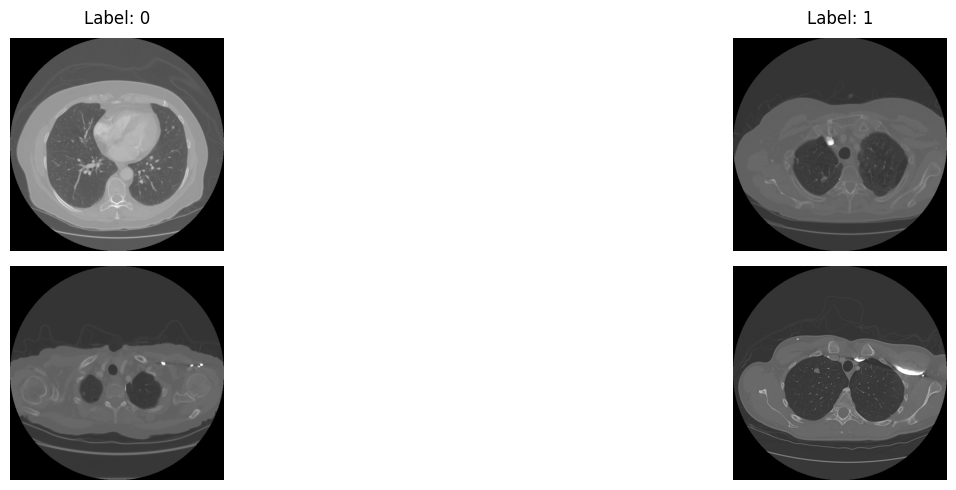

Random Nodule images


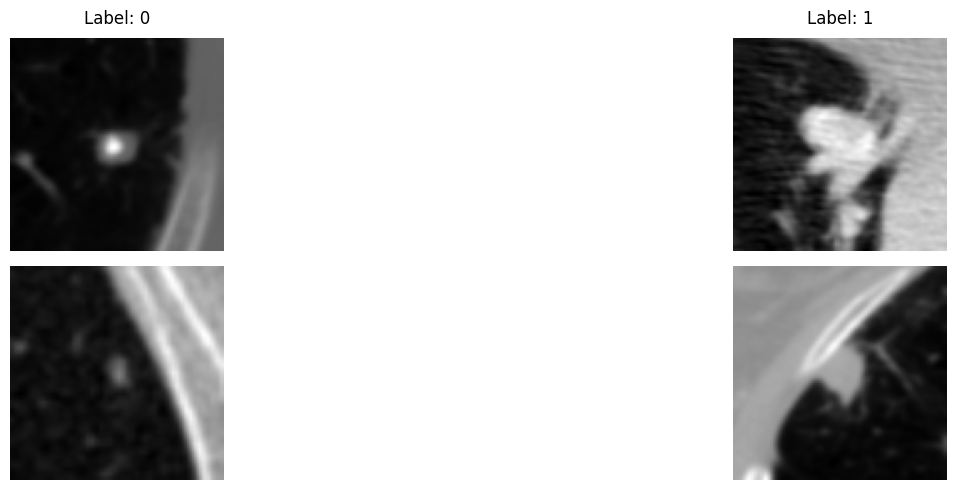

In [33]:
# Plot random images
print("Random Full_slice images")
plot_images(rows=2, images=images_full_slice, labels=labels)
print("Random Nodule images")
plot_images(rows=2, images=images_nodule, labels=labels)


 ### Now let's check for nan values or unexpected image shapes

In [34]:
# Usage example
#check_image_sizes(images_full_slice, images_nodule)


Good, none of the images have nan values or unexpected shapes. Now let's visualize them...

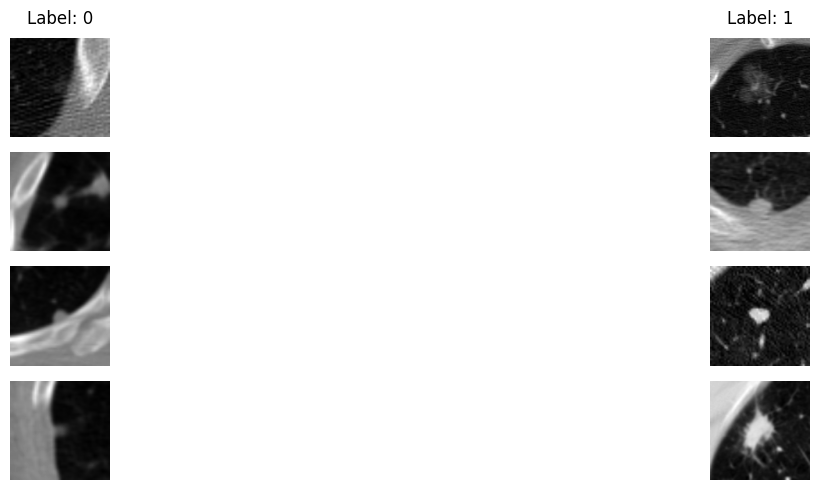

In [35]:
plot_images(4, images_nodule, labels)

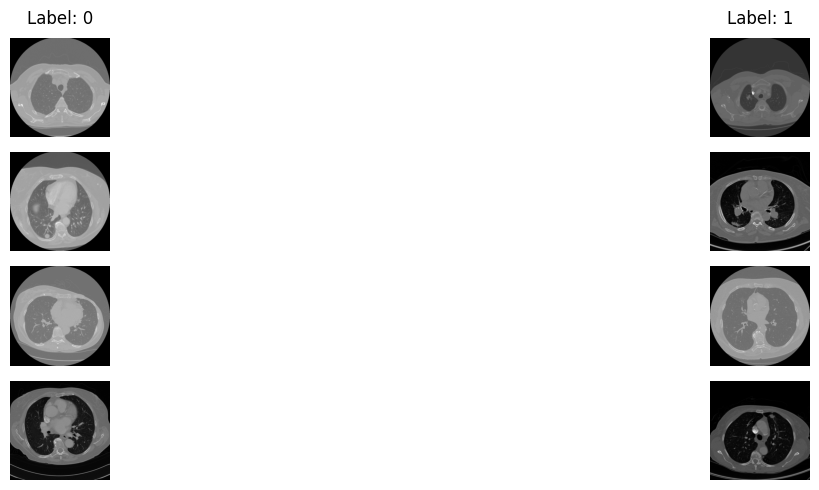

In [36]:
plot_images(4, images_full_slice, labels)

#### By plotting all the images we have identified the indexes of two samples containing this anomaly

In [37]:
'''
# Store the outlier indexes
shrek_index = 11959
rick_index = 13758
'''

'\n# Store the outlier indexes\nshrek_index = 11959\nrick_index = 13758\n'

#### Then we remove Shrek and Rick overlays using these images as templates

To remove them we have used a **template matching** approach:

First we define the two templates by converting the image of Shrek and Rick in grayscale

In [38]:
'''# Load overlay templates
shrek_template = cv2.cvtColor(images[shrek_index], cv2.COLOR_RGB2GRAY)
rick_template = cv2.cvtColor(images[rick_index], cv2.COLOR_RGB2GRAY)

plt.imshow(shrek_template, cmap='gray')
plt.title('Shrek Template')
plt.axis('off')
plt.show()

plt.imshow(rick_template, cmap='gray')
plt.title('Rick Template')
plt.axis('off')
plt.show()
'''

"# Load overlay templates\nshrek_template = cv2.cvtColor(images[shrek_index], cv2.COLOR_RGB2GRAY)\nrick_template = cv2.cvtColor(images[rick_index], cv2.COLOR_RGB2GRAY)\n\nplt.imshow(shrek_template, cmap='gray')\nplt.title('Shrek Template')\nplt.axis('off')\nplt.show()\n\nplt.imshow(rick_template, cmap='gray')\nplt.title('Rick Template')\nplt.axis('off')\nplt.show()\n"

We then use these templates to remove the matching indexes from the dataset by applying the `check_overlay` function. This function, given an image, a template, and a threshold, returns True if the image matches the template at or above the specified similarity threshold.

In [39]:
'''
images, labels, removed_count_per_label = remove_shrek_rick(images, labels, shrek_template, rick_template)

tot_removed_imgs = sum(removed_count_per_label.values())

# Check if any images were removed
if tot_removed_imgs > 0:
    print("Shrek and Rick removed")
    print(f"Total removed images: {tot_removed_imgs}")

    # Print the number of images removed per label
    for label, count in removed_count_per_label.items():
        print(f"Label {label}: Removed {count} images")

else:
    print("No images removed")
'''

'\nimages, labels, removed_count_per_label = remove_shrek_rick(images, labels, shrek_template, rick_template)\n\ntot_removed_imgs = sum(removed_count_per_label.values())\n\n# Check if any images were removed\nif tot_removed_imgs > 0:\n    print("Shrek and Rick removed")\n    print(f"Total removed images: {tot_removed_imgs}")\n\n    # Print the number of images removed per label\n    for label, count in removed_count_per_label.items():\n        print(f"Label {label}: Removed {count} images")\n\nelse:\n    print("No images removed")\n'

Nice!! We removed 1800 outliers! Now it is time to prepare the data to be used for our model training.

In [40]:
# Count occurrences of each label
unique_labels, counts = np.unique(labels, return_counts=True)
num_classes = np.unique(labels).size

print(f"Images are {images_full_slice.shape[1]}x{images_full_slice.shape[2]}")
print(f"There are {images_full_slice.shape[0]} samples")
print(f"Number of distinct labels are {num_classes}")

# Display the counts for each label
for label, count in zip(unique_labels, counts):
    print(f"Label {label}: {count} samples")

Images are 512x512
There are 2363 samples
Number of distinct labels are 2
Label 0: 1793 samples
Label 1: 570 samples


#### As a first step we split the data in train, validation and test sets

In [41]:
# Assuming `full_slice_images` and `nodule_images` are the respective input arrays
'''
X_f = prepared_data['full_slice'].to_numpy()  # Full slice images
X_n = prepared_data['nodule'].to_numpy()      # Nodule images
y = prepared_data['malignancy'].to_numpy()    # Labels
'''
X_f = images_full_slice
#X_n = images_nodule
y = labels


The **validation** set will help to evaluate the model during the training and
for hyperparameter tuning.

The **test** set will help to evaluate the model's performance on unseen data.

Split for dataset with 

In [42]:
# Training set (80%) and Validation + Test set (20%)
# We have also used stratification to keep the same class distribution after split
# Split for Full Slice
X_f_train, X_f_temp, y_f_train, y_f_temp = train_test_split(
    X_f, y, test_size=0.2, stratify=y, random_state=RANDOM_SEED
)

X_f_val, X_f_test, y_f_val, y_f_test = train_test_split(
    X_f_temp, y_f_temp, test_size=0.5, stratify=y_f_temp, random_state=RANDOM_SEED
)
'''
# Split for Nodule
X_n_train, X_n_temp, y_n_train, y_n_temp = train_test_split(
    X_n, y, test_size=0.2, stratify=y, random_state=RANDOM_SEED
)

X_n_val, X_n_test, y_n_val, y_n_test = train_test_split(
    X_n_temp, y_n_temp, test_size=0.5, stratify=y_n_temp, random_state=RANDOM_SEED
)



# Print dataset sizes for verification
print("\nFull Slice Data Splits:")
print(f"Training set size: {len(X_f_train)}")
print(f"Validation set size: {len(X_f_val)}")
print(f"Test set size: {len(X_f_test)}")

print("\nNodule Data Splits:")
print(f"Training set size: {len(X_n_train)}")
print(f"Validation set size: {len(X_n_val)}")
print(f"Test set size: {len(X_n_test)}")
'''

'\n# Split for Nodule\nX_n_train, X_n_temp, y_n_train, y_n_temp = train_test_split(\n    X_n, y, test_size=0.2, stratify=y, random_state=RANDOM_SEED\n)\n\nX_n_val, X_n_test, y_n_val, y_n_test = train_test_split(\n    X_n_temp, y_n_temp, test_size=0.5, stratify=y_n_temp, random_state=RANDOM_SEED\n)\n\n\n\n# Print dataset sizes for verification\nprint("\nFull Slice Data Splits:")\nprint(f"Training set size: {len(X_f_train)}")\nprint(f"Validation set size: {len(X_f_val)}")\nprint(f"Test set size: {len(X_f_test)}")\n\nprint("\nNodule Data Splits:")\nprint(f"Training set size: {len(X_n_train)}")\nprint(f"Validation set size: {len(X_n_val)}")\nprint(f"Test set size: {len(X_n_test)}")\n'

In [43]:
'''
print("Sample from X_f_train:", X_f_train[0])
print("Type of X_f_train[0]:", type(X_f_train[0]))

print("Sample from X_n_train:", X_n_train[0])
print("Type of X_n_train[0]:", type(X_n_train[0]))
'''

'\nprint("Sample from X_f_train:", X_f_train[0])\nprint("Type of X_f_train[0]:", type(X_f_train[0]))\n\nprint("Sample from X_n_train:", X_n_train[0])\nprint("Type of X_n_train[0]:", type(X_n_train[0]))\n'


Label Distributions for Full Slice:


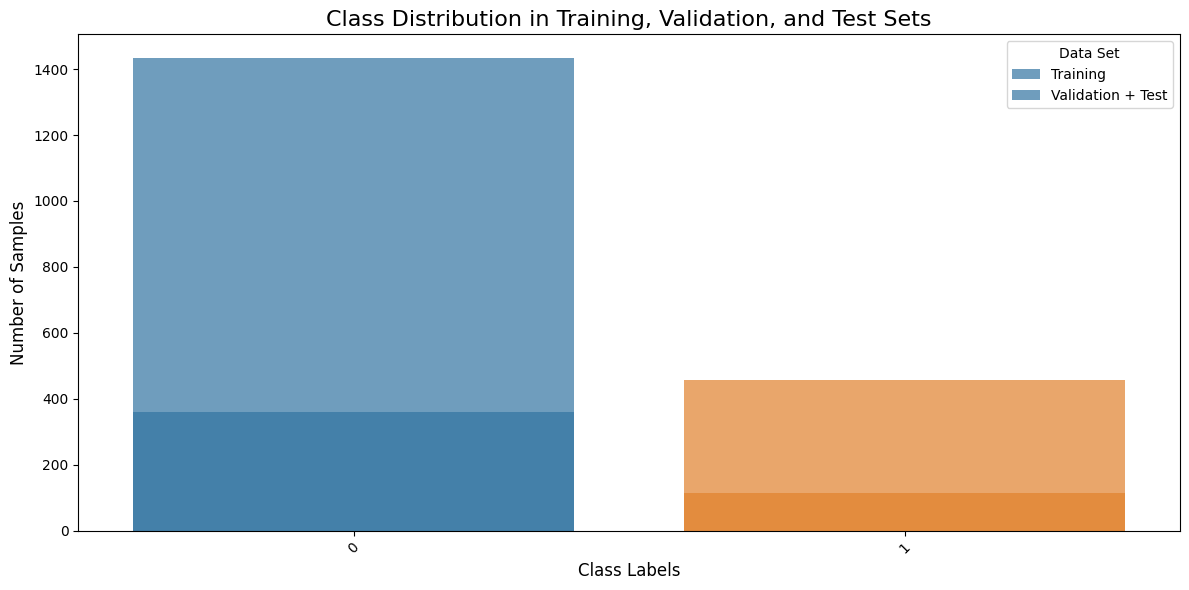

'\nprint("\nLabel Distributions for Nodule:")\nplot_labels_distribution(y_n_train, y_n_val, y_n_test)\n'

In [44]:
# Plot label distributions for both inputs
print("\nLabel Distributions for Full Slice:")
plot_labels_distribution(y_f_train, y_f_val, y_f_test)
'''
print("\nLabel Distributions for Nodule:")
plot_labels_distribution(y_n_train, y_n_val, y_n_test)
'''

To address the class imbalance in the dataset, we have used two approaches:

- **Compute class weights:** This helps to give more importance to the minority classes during training by adjusting the loss function, so the model pays more attention to underrepresented classes.

- **Increase the number of samples in the minority classes:** This is done using simple data augmentation techniques to artificially expand the dataset and provide the model with more diverse examples from underrepresented classes.

In [45]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Flatten the training labels for Full Slice
y_f_train_flat = y_f_train.ravel()

# Compute class weights for Full Slice
unique_labels_f = np.unique(y_f_train_flat)
class_weights_f = compute_class_weight(
    class_weight='balanced',
    classes=unique_labels_f,
    y=y_f_train_flat
)
class_weight_dict_f = dict(enumerate(class_weights_f))
del y_f_train_flat

print("\nClass Weights for Full Slice:")
print(class_weight_dict_f)

'''
# Flatten the training labels for Nodule
y_n_train_flat = y_n_train.ravel()

# Compute class weights for Nodule
unique_labels_n = np.unique(y_n_train_flat)
class_weights_n = compute_class_weight(
    class_weight='balanced',
    classes=unique_labels_n,
    y=y_n_train_flat
)
class_weight_dict_n = dict(enumerate(class_weights_n))
del y_n_train_flat

print("\nClass Weights for Nodule:")
print(class_weight_dict_n)
'''


Class Weights for Full Slice:
{0: 0.6589958158995816, 1: 2.0723684210526314}


'\n# Flatten the training labels for Nodule\ny_n_train_flat = y_n_train.ravel()\n\n# Compute class weights for Nodule\nunique_labels_n = np.unique(y_n_train_flat)\nclass_weights_n = compute_class_weight(\n    class_weight=\'balanced\',\n    classes=unique_labels_n,\n    y=y_n_train_flat\n)\nclass_weight_dict_n = dict(enumerate(class_weights_n))\ndel y_n_train_flat\n\nprint("\nClass Weights for Nodule:")\nprint(class_weight_dict_n)\n'

#### Prepare the dataset for augmentations

To prepare the dataset for image augmentations, we define several functions. Some augmentations, like CutMix and MixUp, require the data to be structured as a dictionary containing two key elements:

- A tensor of **images**
- A tensor of **labels** (one-hot encoded)

These functions will help ensure that the data is properly formatted for these specific augmentation techniques.

In [46]:
# Define image sizes for different input types
FULL_SLICE_IMAGE_SIZE = (512, 512)
NODULE_IMAGE_SIZE = (128, 128)  # Example size for nodules
BATCH_SIZE = 32

def to_dict(image, label, input_type="Full Slice"):
    """
    Transform image and label into the desired format.
    
    Parameters:
    - image: The input image tensor.
    - label: The corresponding label tensor.
    - input_type: Specifies whether the image is "Full Slice" or "Nodule".
    
    Returns:
    - A dictionary with transformed images and labels.
    """
    print("Shape image:", image.shape if hasattr(image, 'shape') else "No shape")
    print("Shape label:", label.shape if hasattr(label, 'shape') else "No shape")

    # Select image size based on input type
    if input_type == "Nodule":
        image_size = NODULE_IMAGE_SIZE
    else:  # Default to "Full Slice"
        image_size = FULL_SLICE_IMAGE_SIZE
        
    height, width = image_size
    
    # Add a channel dimension if the image is grayscale
    if tf.rank(image) == 2:
        image = tf.expand_dims(image, axis=-1)
        image = tf.image.grayscale_to_rgb(image)
        

    # Rescale the pixel values to the range [0, 255]
    image = (image - tf.reduce_min(image)) / (tf.reduce_max(image) - tf.reduce_min(image)) * 255.0

    # Set a known shape and resize the image
    image.set_shape((height, width, 3))  # Allow flexibility in dimensions
    #image = tf.image.resize(image, image_size)
    image = tf.cast(image, tf.float32)

    # One-hot encode the label
    if num_classes > 2:
        label = tfk.utils.to_categorical(label, num_classes)

    print("Transformed - Shape image:", image.shape)
    print("Transformed - Shape label:", label.shape)

    return {"images": image, "labels": label}

def prepare_dataset(dataset, split='train', input_type="Full Slice"):
    if split == 'train':
        return (
            dataset.shuffle(10 * BATCH_SIZE)
            .map(lambda img, lbl: to_dict(img, lbl, input_type), num_parallel_calls=tf.data.AUTOTUNE)
            .batch(BATCH_SIZE)
        )
    elif split == 'validation' or split == 'test':
        return (
            dataset.map(lambda img, lbl: to_dict(img, lbl, input_type), num_parallel_calls=tf.data.AUTOTUNE)
            .batch(BATCH_SIZE)
        )

def load_dataset(data, split='train', input_type="Full Slice"):
    return prepare_dataset(data, split, input_type)

def visualize_dataset(dataset, title):
    plt.figure(figsize=(6, 6)).suptitle(title, fontsize=18)
    for i, samples in enumerate(iter(dataset.take(9))):
        images = samples["images"]
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[0].numpy().astype("uint8"))
        plt.axis("off")
    plt.show()


In [47]:
# Used to convert two numpy arrays (X: input features and y: target values) to a tensor dataset
def to_tensor_dataset(X, y):
  X_tensor = tf.convert_to_tensor(X, dtype=tf.float32)
  y_tensor = tf.convert_to_tensor(y, dtype=tf.uint8)

  return tf.data.Dataset.from_tensor_slices((X_tensor, y_tensor))

In [48]:
# Check for irregular shapes in X_f_train
print("\nChecking shapes in X_f_train:")
for i, sample in enumerate(X_f_train):
    print(f"Sample {i} shape: {sample.shape}")
    if i > 10:  # Limit to first 10 samples
        break
'''
# Check for irregular shapes in X_n_train
print("\nChecking shapes in X_n_train:")
for i, sample in enumerate(X_n_train):
    print(f"Sample {i} shape: {sample.shape}")
    if i > 10:  # Limit to first 10 samples
        break
'''


Checking shapes in X_f_train:
Sample 0 shape: (512, 512)
Sample 1 shape: (512, 512)
Sample 2 shape: (512, 512)
Sample 3 shape: (512, 512)
Sample 4 shape: (512, 512)
Sample 5 shape: (512, 512)
Sample 6 shape: (512, 512)
Sample 7 shape: (512, 512)
Sample 8 shape: (512, 512)
Sample 9 shape: (512, 512)
Sample 10 shape: (512, 512)
Sample 11 shape: (512, 512)


'\n# Check for irregular shapes in X_n_train\nprint("\nChecking shapes in X_n_train:")\nfor i, sample in enumerate(X_n_train):\n    print(f"Sample {i} shape: {sample.shape}")\n    if i > 10:  # Limit to first 10 samples\n        break\n'

problem with shape of nodule images because it's not fixed and all the images are grey images

In [49]:
print("X_f_train shape:", np.shape(X_f_train), "dtype:", type(X_f_train))
print("y_f_train shape:", np.shape(y_f_train), "dtype:", type(y_f_train))
'''
print("X_n_train shape:", np.shape(X_n_train), "dtype:", type(X_n_train))
print("y_n_train shape:", np.shape(y_n_train), "dtype:", type(y_n_train))
'''

X_f_train shape: (1890, 512, 512) dtype: <class 'numpy.ndarray'>
y_f_train shape: (1890,) dtype: <class 'numpy.ndarray'>


'\nprint("X_n_train shape:", np.shape(X_n_train), "dtype:", type(X_n_train))\nprint("y_n_train shape:", np.shape(y_n_train), "dtype:", type(y_n_train))\n'

In [50]:

# Convert datasets separately for full_slice and nodule
train_dataset_f = to_tensor_dataset(X_f_train, y_f_train)
val_dataset_f = to_tensor_dataset(X_f_val, y_f_val)
test_dataset_f = to_tensor_dataset(X_f_test, y_f_test)

'''
train_dataset_n = to_tensor_dataset(X_n_train, y_n_train)
val_dataset_n = to_tensor_dataset(X_n_val, y_n_val)
test_dataset_n = to_tensor_dataset(X_n_test, y_n_test)

'''

'\ntrain_dataset_n = to_tensor_dataset(X_n_train, y_n_train)\nval_dataset_n = to_tensor_dataset(X_n_val, y_n_val)\ntest_dataset_n = to_tensor_dataset(X_n_test, y_n_test)\n\n'

In [51]:
for sample in train_dataset_f.take(1):
    print("Sample:", sample)
    print("Image shape:", sample[0].shape if hasattr(sample[0], 'shape') else "No shape")
    print("Label shape:", sample[1].shape if hasattr(sample[1], 'shape') else "No shape")

for sample in train_dataset_f.take(5):
    print("Image shape:", sample[0].shape)
    
for sample in train_dataset_f.take(5):
    print("Valid image:", sample[0] is not None)


Sample: (<tf.Tensor: shape=(512, 512), dtype=float32, numpy=
array([[ -946.,  -977., -1010., ...,  -950.,  -979., -1011.],
       [ -991.,  -960.,  -967., ...,  -942., -1007., -1023.],
       [-1015.,  -997.,  -979., ...,  -966., -1024., -1024.],
       ...,
       [-1020., -1002., -1001., ...,  -977., -1012., -1007.],
       [-1005.,  -985.,  -984., ...,  -958.,  -990., -1019.],
       [ -965.,  -972.,  -972., ..., -1005.,  -994.,  -995.]],
      dtype=float32)>, <tf.Tensor: shape=(), dtype=uint8, numpy=0>)
Image shape: (512, 512)
Label shape: ()
Image shape: (512, 512)
Image shape: (512, 512)
Image shape: (512, 512)
Image shape: (512, 512)
Image shape: (512, 512)
Valid image: True
Valid image: True
Valid image: True
Valid image: True
Valid image: True


In [52]:
# Prepare TensorFlow datasets for full_slice
train_dataset_f = load_dataset(train_dataset_f, input_type="Full Slice")
val_dataset_f = load_dataset(val_dataset_f, 'validation', input_type="Full Slice")
test_dataset_f = load_dataset(test_dataset_f, 'test', input_type="Full Slice")
'''
# Prepare TensorFlow datasets for nodule
train_dataset_n = load_dataset(train_dataset_n, input_type="Nodule")
val_dataset_n = load_dataset(val_dataset_n, 'validation', input_type="Nodule")
test_dataset_n = load_dataset(test_dataset_n, 'test', input_type="Nodule")
'''

Shape image: (512, 512)
Shape label: ()
Transformed - Shape image: (512, 512, 3)
Transformed - Shape label: ()
Shape image: (512, 512)
Shape label: ()
Transformed - Shape image: (512, 512, 3)
Transformed - Shape label: ()
Shape image: (512, 512)
Shape label: ()
Transformed - Shape image: (512, 512, 3)
Transformed - Shape label: ()


'\n# Prepare TensorFlow datasets for nodule\ntrain_dataset_n = load_dataset(train_dataset_n, input_type="Nodule")\nval_dataset_n = load_dataset(val_dataset_n, \'validation\', input_type="Nodule")\ntest_dataset_n = load_dataset(test_dataset_n, \'test\', input_type="Nodule")\n'

In [53]:
for batch in train_dataset_f.take(1):
    print(batch["images"].shape)
    print(batch["labels"].shape)


(32, 512, 512, 3)
(32,)


In [54]:
'''
for batch in train_dataset_n.take(1):
    print(batch["images"].shape)
    print(batch["labels"].shape)
    '''

'\nfor batch in train_dataset_n.take(1):\n    print(batch["images"].shape)\n    print(batch["labels"].shape)\n    '

In [55]:
#train_dataset_n

# 🪄 Data augmentation

After processing the data, we experimented with various **augmentations** to improve the generalization ability of our model on unseen data.

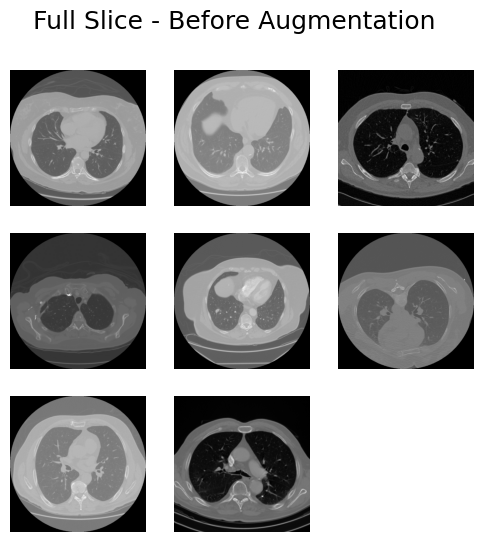

In [56]:
# Visualize Full Slice Dataset Before Augmentation
tmp_data_f = test_dataset_f
visualize_dataset(tmp_data_f, "Full Slice - Before Augmentation")
del tmp_data_f

In [57]:
import tensorflow as tf
import keras_cv
import albumentations as A
import cv2
import numpy as np

# FourierMix layer
fourier_mix = keras_cv.layers.FourierMix(alpha=0.5, decay_power=3)

def apply_fourier_mix(samples):
    """Applies FourierMix augmentation and ensures labels remain correct for binary classification."""
    samples['labels'] = tf.cast(samples['labels'], tf.float32)  # Converte in float32

    augmented_samples = fourier_mix(samples, training=True)  # Applica FourierMix
    
    # Controlla se le etichette sono binarie (devono contenere solo 0 e 1)
    unique_labels = tf.unique(samples['labels'])[0]  # Ottiene i valori unici presenti nei label
    if tf.reduce_all(tf.logical_or(tf.equal(unique_labels, 0), tf.equal(unique_labels, 1))):
        augmented_samples['labels'] = tf.cast(augmented_samples['labels'] > 0.5, tf.float32)  # Riconverti solo se binario

    return augmented_samples
'''
def apply_fourier_mix(samples):
    """Applies FourierMix augmentation to the images in the samples."""
    samples['labels'] = tf.cast(samples['labels'], tf.float32)  # Convert labels
    augmented_samples = fourier_mix(samples, training=True)
    return augmented_samples
'''
'''
tmp_data_f = test_dataset_f
visualize_dataset(tmp_data_f.map(apply_fourier_mix, num_parallel_calls=tf.data.AUTOTUNE), "Full Slice - After Fourier Mix")
del tmp_data_f
'''

'\ntmp_data_f = test_dataset_f\nvisualize_dataset(tmp_data_f.map(apply_fourier_mix, num_parallel_calls=tf.data.AUTOTUNE), "Full Slice - After Fourier Mix")\ndel tmp_data_f\n'

In [58]:

# Define AugMix augmentation
aug_mix = keras_cv.layers.AugMix((0, 255), severity=0.6, num_chains=5, chain_depth=[1, 5])

def apply_aug_mix(samples):
    """Applies AugMix augmentation and ensures labels remain correct for binary classification."""
    samples['labels'] = tf.cast(samples['labels'], tf.float32)  # Converte in float32
    samples['images'] = aug_mix(samples['images'])  # Applica AugMix

    # Controlla se le etichette sono binarie
    unique_labels = tf.unique(samples['labels'])[0]
    if tf.reduce_all(tf.logical_or(tf.equal(unique_labels, 0), tf.equal(unique_labels, 1))):
        samples['labels'] = tf.cast(samples['labels'] > 0.5, tf.float32)  # Riconverti solo se binario
        
    return samples
'''
def apply_aug_mix(samples):
    """
    Applies AugMix augmentation to the images in the samples.
    """
    images = samples['images']
    samples['images'] = aug_mix(images)
    return samples
'''
'''
tmp_data_f = test_dataset_f
visualize_dataset(tmp_data_f.map(apply_aug_mix, num_parallel_calls=tf.data.AUTOTUNE), "Full Slice - After AugMix")
del tmp_data_f
'''

'\ntmp_data_f = test_dataset_f\nvisualize_dataset(tmp_data_f.map(apply_aug_mix, num_parallel_calls=tf.data.AUTOTUNE), "Full Slice - After AugMix")\ndel tmp_data_f\n'

In [59]:
layers = keras_cv.layers.RandAugment.get_standard_policy(
    value_range=(0, 255), magnitude=0.5, magnitude_stddev=0.25
)

layers = layers + [keras_cv.layers.GridMask()]

pipeline = keras_cv.layers.RandomAugmentationPipeline(
    layers=layers, augmentations_per_image=3
)

def apply_pipeline(inputs):
    inputs["images"] = pipeline(inputs["images"])
    return inputs
'''
tmp_data_f = test_dataset_f
visualize_dataset(tmp_data_f.map(apply_pipeline, num_parallel_calls=tf.data.AUTOTUNE), "Full Slice - After RandAug and GradMix")
del tmp_data_f
'''

'\ntmp_data_f = test_dataset_f\nvisualize_dataset(tmp_data_f.map(apply_pipeline, num_parallel_calls=tf.data.AUTOTUNE), "Full Slice - After RandAug and GradMix")\ndel tmp_data_f\n'

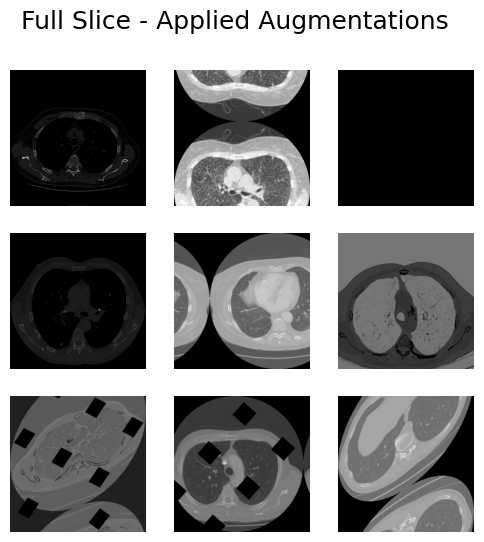

In [60]:
# Apply augmentations to Full Slice Training Dataset
#train_dataset_f = train_dataset_f.map(apply_aug_mix, num_parallel_calls=tf.data.AUTOTUNE)
#train_dataset_f = train_dataset_f.map(apply_fourier_mix, num_parallel_calls=tf.data.AUTOTUNE)

train_dataset_f = train_dataset_f.map(apply_pipeline, num_parallel_calls=tf.data.AUTOTUNE)

# Visualize Full Slice Training Dataset with Applied Augmentations
visualize_dataset(train_dataset_f, "Full Slice - Applied Augmentations")

In [61]:
for batch in train_dataset_f.take(1):
    print(batch["images"].shape)
    print(batch["labels"].shape)

(32, 512, 512, 3)
(32,)


In [62]:
def revert_to_numpy(dataset):
  # Lists to accumulate images and labels
  all_images = []
  all_labels = []

  # Iterate over the dataset
  for batch in dataset:
      images = batch['images']  # Access the images
      labels = batch['labels']  # Access the labels

      # Append the data to the lists
      all_images.append(images.numpy())  # Convert tensor to numpy array and append
      all_labels.append(labels.numpy())  # Convert tensor to numpy array and append

  # Convert the lists to numpy arrays
  X_train = np.concatenate(all_images, axis=0)  # Concatenate all images
  y_train = np.concatenate(all_labels, axis=0)  # Concatenate all labels

  return X_train, y_train

In [63]:

# Revert `full_slice` datasets to NumPy
X_train_f, y_train_f = revert_to_numpy(train_dataset_f)
X_val_f, y_val_f = revert_to_numpy(val_dataset_f)
X_test_f, y_test_f = revert_to_numpy(test_dataset_f)
'''
# Revert `nodule` datasets to NumPy
X_train_n, y_train_n = revert_to_numpy(train_dataset_n)
X_val_n, y_val_n = revert_to_numpy(val_dataset_n)
X_test_n, y_test_n = revert_to_numpy(test_dataset_n)

# Verify the shapes of the converted data
print(f"Full Slice - Training Data: {X_train_f.shape}, Labels: {y_train_f.shape}")
print(f"Full Slice - Validation Data: {X_val_f.shape}, Labels: {y_val_f.shape}")
print(f"Full Slice - Test Data: {X_test_f.shape}, Labels: {y_test_f.shape}")
print(f"Nodule - Training Data: {X_train_n.shape}, Labels: {y_train_n.shape}")
print(f"Nodule - Validation Data: {X_val_n.shape}, Labels: {y_val_n.shape}")
print(f"Nodule - Test Data: {X_test_n.shape}, Labels: {y_test_n.shape}")
'''

'\n# Revert `nodule` datasets to NumPy\nX_train_n, y_train_n = revert_to_numpy(train_dataset_n)\nX_val_n, y_val_n = revert_to_numpy(val_dataset_n)\nX_test_n, y_test_n = revert_to_numpy(test_dataset_n)\n\n# Verify the shapes of the converted data\nprint(f"Full Slice - Training Data: {X_train_f.shape}, Labels: {y_train_f.shape}")\nprint(f"Full Slice - Validation Data: {X_val_f.shape}, Labels: {y_val_f.shape}")\nprint(f"Full Slice - Test Data: {X_test_f.shape}, Labels: {y_test_f.shape}")\nprint(f"Nodule - Training Data: {X_train_n.shape}, Labels: {y_train_n.shape}")\nprint(f"Nodule - Validation Data: {X_val_n.shape}, Labels: {y_val_n.shape}")\nprint(f"Nodule - Test Data: {X_test_n.shape}, Labels: {y_test_n.shape}")\n'

In [ ]:
print(f"Min pixel value: {tf.reduce_min(X_train_f).numpy()}")
print(f"Max pixel value: {tf.reduce_max(X_train_f).numpy()}")

In [64]:
def augment_dataset(dataset, target_class, num_augmentations_per_sample):
    """Efficiently augments a dataset without excessive memory usage."""
    
    def augment_sample(sample):
        img, label = sample["images"], sample["labels"]
        
        # Apply augmentations only if the sample belongs to the target class
        augmented_images = tf.cond(
            tf.equal(label, target_class),
            lambda: tf.stack([pipeline(img) for _ in range(num_augmentations_per_sample)]),
            lambda: tf.expand_dims(img, axis=0)  # Keep original if not target class
        )
        
        # Repeat labels to match the augmented images
        augmented_labels = tf.fill((tf.shape(augmented_images)[0],), label)
        
        return {"images": augmented_images, "labels": augmented_labels}

    # Unbatch, apply augmentations per sample, then batch again
    augmented_dataset = dataset.unbatch().map(augment_sample, num_parallel_calls=tf.data.AUTOTUNE)
    
    # Flatten back into a normal dataset
    augmented_dataset = augmented_dataset.unbatch().batch(BATCH_SIZE)

    return augmented_dataset


In [66]:
def compute_class_distribution(dataset):
    class_counts = {0: 0, 1: 0}  # Assuming binary classification (adjust for multi-class)
    
    for sample in dataset.take(500):  # Process only a subset for efficiency
        labels = sample["labels"].numpy()
        unique, counts = np.unique(labels, return_counts=True)
        
        for cls, count in zip(unique, counts):
            class_counts[cls] += count
            
    return class_counts

In [67]:
# Set number of augmentations per sample
num_augmentations = 3  # Change as needed

# Apply augmentation to the training dataset
train_dataset_f_aug = augment_dataset(train_dataset_f, target_class=1, num_augmentations_per_sample=num_augmentations)

# Check the new class distribution
new_class_distribution = compute_class_distribution(train_dataset_f_aug)
print(f"Class Distribution After Augmentation: {new_class_distribution}")


Class Distribution After Augmentation: {0: 1434, 1: 1368}


In [68]:
def sigmoid_focal_crossentropy(alpha=0.25, gamma=2.0):
    """Custom Sigmoid Focal Cross Entropy Loss for binary classification."""
    def loss(y_true, y_pred):

        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.cast(y_pred, tf.float32)
        # Evita log(0) per stabilità numerica
        epsilon = tf.keras.backend.epsilon()
        y_pred = tf.clip_by_value(y_pred, epsilon, 1. - epsilon)
        
        # Calcola la cross-entropy standard
        cross_entropy = -y_true * tf.math.log(y_pred) - (1 - y_true) * tf.math.log(1 - y_pred)
        
        # Calcola il termine di focalizzazione
        focal_weight = alpha * y_true * (1 - y_pred) ** gamma + (1 - alpha) * (1 - y_true) * y_pred ** gamma
        
        # Calcola la focal loss finale
        focal_loss = focal_weight * cross_entropy
        return tf.reduce_mean(focal_loss)
    
    return loss


In [69]:
# SET BINARY TASK

# 🔹 Definisci il numero di classi (1 per binario, >2 per multi-classe)
output_shape = np.unique(labels).size
# Decide activation function and loss function based on number of classes  
if output_shape > 2:  # Multi-class classification
    loss_fn = "categorical_crossentropy"
else:  # Binary classification
    loss_fn = sigmoid_focal_crossentropy(alpha=0.25, gamma=2.0) # sigmoid_focal_crossentropy(alpha=0.25, gamma=2.0) # as alternative loss=sigmoid_focal_crossentropy(alpha=0.25, gamma=2.0) or "binary_crossentropy"

In [70]:
# FULL SLICE INPUT
# Define training parameters

epochs = 1000 # tanto ci sta early stop
batch_size = 16 # for cnn 16 and before 32

input_shape =(256, 256, 3)#(224, 224, 3) for transformer, (256, 256, 3) for cnn , (512, 512, 3)# X_train_f.shape[1:] # It depends on the type of input we are feeding into our model
output_shape = np.unique(labels).size
learning_rate = 0.001 # TO CHECK 'cause it seems that I overwrite it in the function
class_weight_dict = class_weight_dict_f

In [71]:
def get_callbacks(patience = 10):
  reduce_lr = tfk.callbacks.ReduceLROnPlateau(monitor='val_loss',
                                factor=0.5,  # Reduce by 50%
                                patience=5,
                                min_lr=1e-6)

  # Create an EarlyStopping callback
  early_stopping = tfk.callbacks.EarlyStopping(
      monitor='val_accuracy',
      mode='max',
      patience=patience,
      restore_best_weights=True
  )

  # Store the callback in a list
  callbacks = [early_stopping, reduce_lr]

  return callbacks

# 🛠️ Build the CNN model

#### Create an EarlyStopping callback

In [72]:
X_f.shape

(2363, 512, 512)

In [73]:
print(np.unique(y_train_f, return_counts=True))

(array([0, 1], dtype=uint8), array([1434,  456]))


In [74]:
'''
# NODULE INPUT
# Define training parameters

epochs = 1000 # tanto ci sta early stop
batch_size = 32

input_shape = X_train_n.shape[1:] # It depends on the type of input we are feeding into our model
output_shape = np.unique(labels).size
learning_rate = 0.001
class_weight_dict = class_weight_dict_n
'''

'\n# NODULE INPUT\n# Define training parameters\n\nepochs = 1000 # tanto ci sta early stop\nbatch_size = 32\n\ninput_shape = X_train_n.shape[1:] # It depends on the type of input we are feeding into our model\noutput_shape = np.unique(labels).size\nlearning_rate = 0.001\nclass_weight_dict = class_weight_dict_n\n'

Qui scegliamo quanti layers e neuroni da mettere dopo il modello base per uniformare i risultati con gli altri modelli

In [75]:

def build_model(input_shape=input_shape,
                output_shape=output_shape,
                learning_rate=learning_rate,
                optimizer = tfk.optimizers.Adam(learning_rate),
                base_model=None, preprocessing=None, 
                loss_fn=loss_fn):

  # Input layer
  input_layer = tfkl.Input(shape=input_shape)

  # Preprocess the input (If it is needed by base model)
  if (preprocessing != None):
    x = preprocessing(input_layer)
  else:
    x = input_layer

  if (base_model == None):
    print("Please define a base model!")
    return None, None

  base_model.trainable = False

  x = base_model(x, training=False) # Run on inference mode

  # Add custom layers on top of base model

  x = tfkl.GlobalAveragePooling2D()(x)  # Use GAP instead of Flatten
  # It should be better than BatchNormalization for small batch sizes
  print(x.shape)
  x = tfk.layers.GroupNormalization(groups=32, axis=-1)(x)
  x = tfkl.Dropout(0.3)(x)

  x = tfkl.Dense(128, kernel_regularizer=tfk.regularizers.l2(1e-4))(x)
  x = tfk.activations.gelu(x)  # gelu activation (should be better than leaky relu)
  print(x.shape)
  x = tfk.layers.GroupNormalization(groups=32, axis=-1)(x)
  x = tfkl.Dropout(0.3)(x)

  # x = tfkl.Dense(64, kernel_regularizer=tfk.regularizers.l2(1e-4))(x)
  # x = tfkl.LeakyReLU(alpha=0.1)(x)  # LeakyReLU activation
  # print(x.shape)
  # x = tfk.layers.GroupNormalization(groups=32, axis=-1)(x)
  # x = tfkl.Dropout(0.3)(x)

  # Decide activation function and loss function based on number of classes  
  if output_shape > 2:  # Multi-class classification
      activation = "softmax"
      units = 5
  else:  # Binary classification
      activation = "sigmoid"
      units = 1

  output_layer = tfkl.Dense(units, activation=activation)(x)
    
  model = tf.keras.Model(inputs=input_layer, outputs=output_layer)


  # Compile the model
  model.compile(
      optimizer=optimizer,
      loss=loss_fn, 
      metrics=['accuracy']
  )

  return base_model, model


In [76]:
# 🔹 Squeeze-and-Excitation (SE) Block (Attention Mechanism)
def se_block(input_tensor, reduction=16):
    """Squeeze-and-Excitation (SE) Block to enhance feature learning."""
    filters = input_tensor.shape[-1]  # Number of channels
    se = tfkl.GlobalAveragePooling2D()(input_tensor)  # Squeeze step
    se = tfkl.Dense(filters // reduction, activation="relu")(se)  # Bottleneck
    se = tfkl.Dense(filters, activation="sigmoid")(se)  # Scaling factor
    return tfkl.multiply([input_tensor, se])  # Reweighting features

# 🔹 Modified Build Model with Attention in Classification Head
def build_model_with_attention(input_shape=input_shape,
                output_shape=output_shape,
                learning_rate=learning_rate,
                optimizer = tfk.optimizers.Adam(learning_rate),
                base_model=None, preprocessing=None, 
                loss_fn=loss_fn):
    """Builds a classification model with attention in the head."""

    # Input layer
    input_layer = tfkl.Input(shape=input_shape)

    # Apply preprocessing if needed (EfficientNetV2 requires specific preprocessing)
    if preprocessing:
        x = preprocessing(input_layer)
    else:
        x = input_layer

    # Ensure a base model is provided
    if base_model is None:
        raise ValueError("Please define a base model!")

    # Set base model to non-trainable for transfer learning
    base_model.trainable = False

    # Pass input through base model
    x = base_model(x, training=False)

    # 🔹 Apply Attention (Squeeze-and-Excitation Block) at feature level
    x = se_block(x)  # 🔥 Add attention here

    # Global Average Pooling (instead of Flatten)
    x = tfkl.GlobalAveragePooling2D()(x)

    # Normalize features to prevent overfitting
    x = tfkl.GroupNormalization(groups=32, axis=-1)(x)
    x = tfkl.Dropout(0.3)(x)

    # Fully connected layers
    x = tfkl.Dense(128, kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
    x = tf.keras.activations.gelu(x)  # GELU activation
    x = tfkl.GroupNormalization(groups=32, axis=-1)(x)
    x = tfkl.Dropout(0.3)(x)

    # Define activation function based on classification type
    if output_shape > 2:  # Multi-class classification
        activation = "softmax"
        units = output_shape
    else:  # Binary classification
        activation = "sigmoid"
        units = 1

    # Output layer
    output_layer = tfkl.Dense(units, activation=activation)(x)

    # Create model
    model = tf.keras.Model(inputs=input_layer, outputs=output_layer)

    # Compile the model
    model.compile(
        optimizer=optimizer,
        loss=loss_fn, 
        metrics=['accuracy']
      )


    return base_model, model




## 🛠️ Train and save the model

In [77]:
def train_model(model, X_train, y_train, X_val, y_val,
                epochs=epochs, batch_size=batch_size,
                class_weight_dict=class_weight_dict,
                fine_tune_at=0, loss_fn=loss_fn):

  # Train the model
  callbacks = get_callbacks() # patience 10

  history_transfer = model.fit(
      X_train,
      y_train,
      batch_size=batch_size,
      epochs=epochs,
      validation_data=(X_val, y_val),
      class_weight=class_weight_dict,
      callbacks=callbacks
  )

  # 2nd round fine-tune

  callbacks = get_callbacks() # patience 10 and 5 for reducelr

  learning_rate = 1e-5 # Low lr for fine tuning

  # Unfreeze the base model
  base_model.trainable = True

  # Freeze all the layers before the `fine_tune_at` layer
  # Note that fine_tune_at defaults to 0 (All the layers are trainable)
  for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

  optimizer = tf.keras.optimizers.Lion(
      learning_rate=learning_rate,
      beta_1=0.9,
      beta_2=0.99,
      weight_decay=1e-4,
      clipnorm=1.0, # To avoid exploding gradients
  )

  # Compile the model
  model.compile(
    optimizer=optimizer,
    loss=loss_fn,
    metrics=['accuracy']
  )

  # The initial epoch from which the fine tuning starts
  initial_epochs = len(history_transfer.epoch)

  print("\n--------------------- START FINE TUNING ---------------------\n")

  # Train the model
  history_fine = model.fit(
      X_train,
      y_train,
      batch_size=16,
      epochs=1000,
      initial_epoch=len(history_transfer.epoch), # Init from last epoch
      validation_data=(X_val, y_val),
      class_weight=class_weight_dict,
      callbacks=callbacks
  )

  return history_transfer, history_fine, initial_epochs

In [78]:
input_shape =(256, 256, 3)

In [79]:

#PROVA
target_size = (256, 256)
X_train_f = tf.image.resize(X_train_f, target_size)
X_val_f = tf.image.resize(X_val_f, target_size)
X_test_f = tf.image.resize(X_test_f, target_size)



In [80]:

# For CNN models
X_train_f = X_train_f / 255.0
X_val_f = X_val_f / 255.0
X_test_f = X_test_f / 255.0


'\n# For CNN models\nX_train_f = X_train_f / 255.0\nX_val_f = X_val_f / 255.0\nX_test_f = X_test_f / 255.0\n'

In [ ]:
print(f"Min pixel value: {tf.reduce_min(X_train_f).numpy()}")
print(f"Max pixel value: {tf.reduce_max(X_train_f).numpy()}")

# 🛠️ Build the model: EfficientNetV2S

In [81]:
tf.keras.mixed_precision.set_global_policy('mixed_float16')


weight_decay = 1e-4

optimizer = tfk.optimizers.Lion(
    learning_rate=learning_rate, #start transfer learning with "high" lr 0.001
    weight_decay=weight_decay,
    clipnorm=1.0,
    )

# Define the base model to fine tune
model_name = "EfficientNetV2S"
model_to_fine_tune = tfk.applications.EfficientNetV2S(weights="imagenet",
                          input_shape=input_shape,
                          include_top=False)

base_model, model = build_model(optimizer=optimizer, learning_rate=learning_rate,
                                base_model=model_to_fine_tune, loss_fn=loss_fn)

model.summary()
print(f"Number of layers in {model_name} are {len(base_model.layers)}")

(None, 1280)
(None, 128)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 256, 256, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ efficientnetv2-s (Functional)        │ (None, 8, 8, 1280)          │      20,331,360 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ group_normalization                  │ (None, 1280)                │           2,560 │
│ (GroupNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 1280)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         163,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gelu (Gelu)                          │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ group_normalization_1                │ (None, 128)                 │             256 │
│ (GroupNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 20,498,273 (78.19 MB)

 Trainable params: 166,913 (652.00 KB)

 Non-trainable params: 20,331,360 (77.56 MB)

Number of layers in EfficientNetV2S are 513


Train model on Full Slice images

In [82]:
print(y_train_f.shape)  # Dovrebbe essere (num_samples, 2) → Questo è sbagliato!
print(y_train_f[:5])    # Dovrebbe stampare array tipo [[1,0], [0,1], ...]


(1890,)
[0 1 0 0 1]


In [83]:
'''
if num_classes > 2:
    y_train_f = np.argmax(y_train_f, axis=1)
    y_val_f = np.argmax(y_val_f, axis=1)
    y_test_f = np.argmax(y_test_f, axis=1)  # Se serve anche per test set
'''


'\nif num_classes > 2:\n    y_train_f = np.argmax(y_train_f, axis=1)\n    y_val_f = np.argmax(y_val_f, axis=1)\n    y_test_f = np.argmax(y_test_f, axis=1)  # Se serve anche per test set\n'

In [84]:

print(y_train_f.shape)  # Dovrebbe ora essere (1890,)
print(y_train_f[:5])    # Dovrebbe stampare array tipo [0, 1, 1, 0, 1]



(1890,)
[0 1 0 0 1]


In [85]:
# This includes transfer learning + fine tuning
# Train on Full Slice
print("\nTraining on Full Slice Data...")
history_transfer_f, history_fine_f, initial_epochs_f = train_model(
    model,
    X_train_f,  # Full slice training data
    y_train_f,  # Full slice training labels
    X_val_f,    # Full slice validation data
    y_val_f,    # Full slice validation labels
    epochs=epochs,
    batch_size=batch_size,
    class_weight_dict=class_weight_dict,  # Ensure weights are for this dataset
    fine_tune_at=-30,  # Adjust fine-tuning start layer if needed
    loss_fn=loss_fn
)


Training on Full Slice Data...
Epoch 1/1000
119/119 ━━━━━━━━━━━━━━━━━━━━ 99s 393ms/step - accuracy: 0.6899 - loss: 0.1709 - val_accuracy: 0.7585 - val_loss: 0.1827 - learning_rate: 0.0010
Epoch 2/1000
119/119 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - accuracy: 0.7492 - loss: 0.2376 - val_accuracy: 0.7585 - val_loss: 0.2527 - learning_rate: 0.0010
Epoch 3/1000
119/119 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - accuracy: 0.7521 - loss: 0.2221 - val_accuracy: 0.7585 - val_loss: 0.1143 - learning_rate: 0.0010
Epoch 4/1000
119/119 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - accuracy: 0.7545 - loss: 0.1075 - val_accuracy: 0.7585 - val_loss: 0.0862 - learning_rate: 0.0010
Epoch 5/1000
119/119 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - accuracy: 0.7515 - loss: 0.0907 - val_accuracy: 0.7585 - val_loss: 0.0807 - learning_rate: 0.0010
Epoch 6/1000
119/119 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - accuracy: 0.7521 - loss: 0.0839 - val_accuracy: 0.7585 - val_loss: 0.0806 - learning_rate: 0.0010
Epoch 7/1000
119/119 ━━━━━━━━━━━━━━━

Train the model on Nodule images

In [86]:
'''
# Train on Nodule
print("\nTraining on Nodule Data...")
history_transfer_n, history_fine_n, initial_epochs_n = train_model(
    model,
    X_train_n,  # Nodule training data
    y_train_n,  # Nodule training labels
    X_val_n,    # Nodule validation data
    y_val_n,    # Nodule validation labels
    epochs=epochs,
    batch_size=batch_size,
    class_weight_dict=class_weight_dict,  # Ensure weights are for this dataset
    fine_tune_at=0  # Adjust fine-tuning start layer if needed
)
'''

'\n# Train on Nodule\nprint("\nTraining on Nodule Data...")\nhistory_transfer_n, history_fine_n, initial_epochs_n = train_model(\n    model,\n    X_train_n,  # Nodule training data\n    y_train_n,  # Nodule training labels\n    X_val_n,    # Nodule validation data\n    y_val_n,    # Nodule validation labels\n    epochs=epochs,\n    batch_size=batch_size,\n    class_weight_dict=class_weight_dict,  # Ensure weights are for this dataset\n    fine_tune_at=0  # Adjust fine-tuning start layer if needed\n)\n'

# Model evaluation 📈

In [87]:
# Create dictionaries to store metrics for Full Slice and Nodule models
model_acc = {"Full Slice": {}, "Nodule": {}}
model_pre = {"Full Slice": {}, "Nodule": {}}
model_rec = {"Full Slice": {}, "Nodule": {}}
model_auc = {"Full Slice": {}, "Nodule": {}}
model_conf = {"Full Slice": {}, "Nodule": {}}


In [88]:
# Evaluate Full Slice Model
print("\nEvaluating Full Slice Model...")
test_acc_f, test_pre_f, test_rec_f, test_auc_f, test_conf_f = evaluate_model_with_confidence(
    model, X_test_f, y_test_f
)
model_acc["Full Slice"][model_name] = test_acc_f
model_pre["Full Slice"][model_name] = test_pre_f
model_rec["Full Slice"][model_name] = test_rec_f
model_auc["Full Slice"][model_name] = test_auc_f
model_conf["Full Slice"][model_name] = test_conf_f
'''
# Evaluate Nodule Model
print("\nEvaluating Nodule Model...")
test_acc_n, test_pre_n, test_rec_n, test_auc_n, test_conf_n = evaluate_model_with_confidence(
    model, X_test_n, y_test_n
)
model_acc["Nodule"][model_name] = test_acc_n
model_pre["Nodule"][model_name] = test_pre_n
model_rec["Nodule"][model_name] = test_rec_n
model_auc["Nodule"][model_name] = test_auc_n
model_conf["Nodule"][model_name] = test_conf_n
'''
# Print results for both models
print("\nModel Evaluation Metrics:")
print("Full Slice Model:")
print(
    f"Accuracy: {test_acc_f:.4f}, Precision: {test_pre_f:.4f}, Recall: {test_rec_f:.4f}, AUC: {test_auc_f:.4f}, Confidence: {test_conf_f:.4f}"
)
'''
print("\nNodule Model:")
print(
    f"Accuracy: {test_acc_n:.4f}, Precision: {test_pre_n:.4f}, Recall: {test_rec_n:.4f}, AUC: {test_auc_n:.4f}, Confidence: {test_conf_n:.4f}"
)
'''


Evaluating Full Slice Model...
8/8 ━━━━━━━━━━━━━━━━━━━━ 22s 2s/step
Test Loss: 0.1793
Test Accuracy: 0.7595
Precision (weighted): 0.6988
Recall (weighted): 0.7595
ROC AUC (weighted): 0.5623
Average Confidence: 0.2406

Model Evaluation Metrics:
Full Slice Model:
Accuracy: 0.7595, Precision: 0.6988, Recall: 0.7595, AUC: 0.5623, Confidence: 0.2406


'\nprint("\nNodule Model:")\nprint(\n    f"Accuracy: {test_acc_n:.4f}, Precision: {test_pre_n:.4f}, Recall: {test_rec_n:.4f}, AUC: {test_auc_n:.4f}, Confidence: {test_conf_n:.4f}"\n)\n'


Confusion Matrix for Full Slice Model:
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


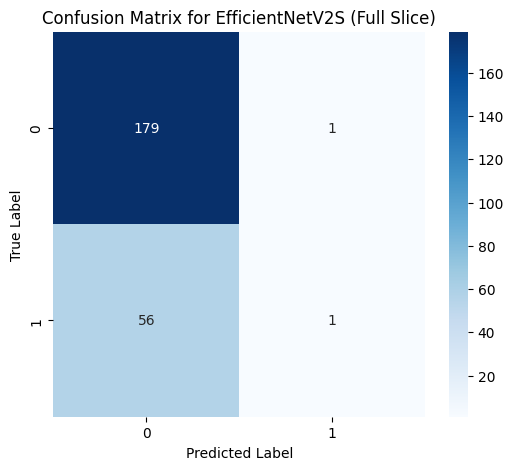

'\n# Plot confusion matrix for Nodule Model\nprint("\nConfusion Matrix for Nodule Model:")\nplot_confusion_matrix(model, X_test_n, y_test_n, f"{model_name} (Nodule)")\n'

In [89]:
# Plot confusion matrix for Full Slice Model
print("\nConfusion Matrix for Full Slice Model:")
plot_confusion_matrix(model, X_test_f, y_test_f, f"{model_name} (Full Slice)")

'''
# Plot confusion matrix for Nodule Model
print("\nConfusion Matrix for Nodule Model:")
plot_confusion_matrix(model, X_test_n, y_test_n, f"{model_name} (Nodule)")
'''

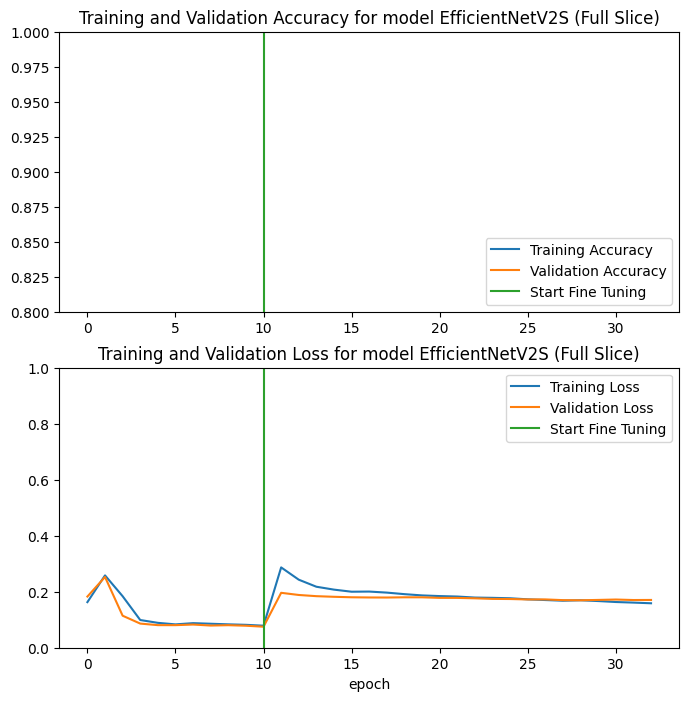

In [90]:
plot_training_val_accuracy(history_transfer_f, history_fine_f, initial_epochs_f, f"{model_name} (Full Slice)")
#plot_training_val_accuracy(history_transfer_n, history_fine_n, initial_epochs_n, f"{model_name} (Nodule)")

In [91]:
model.save(f'{model_name}_binary_full_slice_withFourierAug_weights.keras')
del model

# 🛠️ Build the model with attention: EfficientNetV2S

In [92]:
tf.keras.mixed_precision.set_global_policy('mixed_float16')


weight_decay = 1e-4

optimizer = tfk.optimizers.Lion(
    learning_rate=learning_rate, #start transfer learning with "high" lr 0.001
    weight_decay=weight_decay,
    clipnorm=1.0,
    )

# Define the base model to fine tune
model_name = "EfficientNetV2S_with_attention"
model_to_fine_tune = tfk.applications.EfficientNetV2S(weights="imagenet",
                          input_shape=input_shape,
                          include_top=False)

base_model, model = build_model_with_attention(optimizer=optimizer, learning_rate=learning_rate,
                                base_model=model_to_fine_tune, loss_fn=loss_fn)

model.summary()
print(f"Number of layers in {model_name} are {len(base_model.layers)}")

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3             │ (None, 256, 256, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ efficientnetv2-s          │ (None, 8, 8, 1280)     │     20,331,360 │ input_layer_3[0][0]    │
│ (Functional)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ global_average_pooling2d… │ (None, 1280)           │              0 │ efficientnetv2-s[0][0] │
│ (GlobalAveragePooling2D)  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_2 (Dense)           │ (None, 80)             │        102,480 │ global_average_poolin… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_3 (Dense)           │ (None, 1280)           │        103,680 │ dense_2[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ multiply (Multiply)       │ (None, 8, 8, 1280)     │              0 │ efficientnetv2-s[0][0… │
│                           │                        │                │ dense_3[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ global_average_pooling2d… │ (None, 1280)           │              0 │ multiply[0][0]         │
│ (GlobalAveragePooling2D)  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ group_normalization_2     │ (None, 1280)           │          2,560 │ global_average_poolin… │
│ (GroupNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_2 (Dropout)       │ (None, 1280)           │              0 │ group_normalization_2… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_4 (Dense)           │ (None, 128)            │        163,968 │ dropout_2[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ gelu_1 (Gelu)             │ (None, 128)            │              0 │ dense_4[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ group_normalization_3     │ (None, 128)            │            256 │ gelu_1[0][0]           │
│ (GroupNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_3 (Dropout)       │ (None, 128)            │              0 │ group_normalization_3… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_5 (Dense)           │ (None, 1)              │            129 │ dropout_3[0][0]        │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 20,704,433 (78.98 MB)

 Trainable params: 373,073 (1.42 MB)

 Non-trainable params: 20,331,360 (77.56 MB)

Number of layers in EfficientNetV2S_with_attention are 513


In [93]:
# This includes transfer learning + fine tuning
# Train on Full Slice
print("\nTraining on Full Slice Data...")
history_transfer_f, history_fine_f, initial_epochs_f = train_model(
    model,
    X_train_f,  # Full slice training data
    y_train_f,  # Full slice training labels
    X_val_f,    # Full slice validation data
    y_val_f,    # Full slice validation labels
    epochs=epochs,
    batch_size=batch_size,
    class_weight_dict=class_weight_dict,  # Ensure weights are for this dataset
    fine_tune_at=-30,  # Adjust fine-tuning start layer if needed
    loss_fn=loss_fn
)


Training on Full Slice Data...
Epoch 1/1000
119/119 ━━━━━━━━━━━━━━━━━━━━ 99s 374ms/step - accuracy: 0.7113 - loss: 0.1714 - val_accuracy: 0.7585 - val_loss: 0.1826 - learning_rate: 0.0010
Epoch 2/1000
119/119 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - accuracy: 0.7318 - loss: 0.2383 - val_accuracy: 0.7585 - val_loss: 0.2465 - learning_rate: 0.0010
Epoch 3/1000
119/119 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - accuracy: 0.7531 - loss: 0.2163 - val_accuracy: 0.7585 - val_loss: 0.1184 - learning_rate: 0.0010
Epoch 4/1000
119/119 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - accuracy: 0.7497 - loss: 0.1137 - val_accuracy: 0.7585 - val_loss: 0.0886 - learning_rate: 0.0010
Epoch 5/1000
119/119 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - accuracy: 0.7516 - loss: 0.0928 - val_accuracy: 0.7585 - val_loss: 0.0823 - learning_rate: 0.0010
Epoch 6/1000
119/119 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - accuracy: 0.7521 - loss: 0.0886 - val_accuracy: 0.7585 - val_loss: 0.0800 - learning_rate: 0.0010
Epoch 7/1000
119/119 ━━━━━━━━━━━━━━━

In [94]:
# Create dictionaries to store metrics for Full Slice and Nodule models
model_acc = {"Full Slice": {}, "Nodule": {}}
model_pre = {"Full Slice": {}, "Nodule": {}}
model_rec = {"Full Slice": {}, "Nodule": {}}
model_auc = {"Full Slice": {}, "Nodule": {}}
model_conf = {"Full Slice": {}, "Nodule": {}}


In [95]:
# Evaluate Full Slice Model
print("\nEvaluating Full Slice Model...")
test_acc_f, test_pre_f, test_rec_f, test_auc_f, test_conf_f = evaluate_model_with_confidence(
    model, X_test_f, y_test_f
)
model_acc["Full Slice"][model_name] = test_acc_f
model_pre["Full Slice"][model_name] = test_pre_f
model_rec["Full Slice"][model_name] = test_rec_f
model_auc["Full Slice"][model_name] = test_auc_f
model_conf["Full Slice"][model_name] = test_conf_f
'''
# Evaluate Nodule Model
print("\nEvaluating Nodule Model...")
test_acc_n, test_pre_n, test_rec_n, test_auc_n, test_conf_n = evaluate_model_with_confidence(
    model, X_test_n, y_test_n
)
model_acc["Nodule"][model_name] = test_acc_n
model_pre["Nodule"][model_name] = test_pre_n
model_rec["Nodule"][model_name] = test_rec_n
model_auc["Nodule"][model_name] = test_auc_n
model_conf["Nodule"][model_name] = test_conf_n
'''
# Print results for both models
print("\nModel Evaluation Metrics:")
print("Full Slice Model:")
print(
    f"Accuracy: {test_acc_f:.4f}, Precision: {test_pre_f:.4f}, Recall: {test_rec_f:.4f}, AUC: {test_auc_f:.4f}, Confidence: {test_conf_f:.4f}"
)
'''
print("\nNodule Model:")
print(
    f"Accuracy: {test_acc_n:.4f}, Precision: {test_pre_n:.4f}, Recall: {test_rec_n:.4f}, AUC: {test_auc_n:.4f}, Confidence: {test_conf_n:.4f}"
)
'''


Evaluating Full Slice Model...
8/8 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step
Test Loss: 0.1908
Test Accuracy: 0.7511
Precision (weighted): 0.5753
Recall (weighted): 0.7511
ROC AUC (weighted): 0.5072
Average Confidence: 0.2581

Model Evaluation Metrics:
Full Slice Model:
Accuracy: 0.7511, Precision: 0.5753, Recall: 0.7511, AUC: 0.5072, Confidence: 0.2581


'\nprint("\nNodule Model:")\nprint(\n    f"Accuracy: {test_acc_n:.4f}, Precision: {test_pre_n:.4f}, Recall: {test_rec_n:.4f}, AUC: {test_auc_n:.4f}, Confidence: {test_conf_n:.4f}"\n)\n'


Confusion Matrix for Full Slice Model:
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


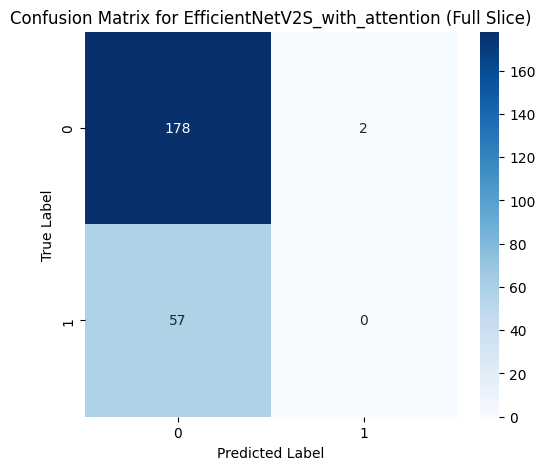

'\n# Plot confusion matrix for Nodule Model\nprint("\nConfusion Matrix for Nodule Model:")\nplot_confusion_matrix(model, X_test_n, y_test_n, f"{model_name} (Nodule)")\n'

In [96]:
# Plot confusion matrix for Full Slice Model
print("\nConfusion Matrix for Full Slice Model:")
plot_confusion_matrix(model, X_test_f, y_test_f, f"{model_name} (Full Slice)")

'''
# Plot confusion matrix for Nodule Model
print("\nConfusion Matrix for Nodule Model:")
plot_confusion_matrix(model, X_test_n, y_test_n, f"{model_name} (Nodule)")
'''

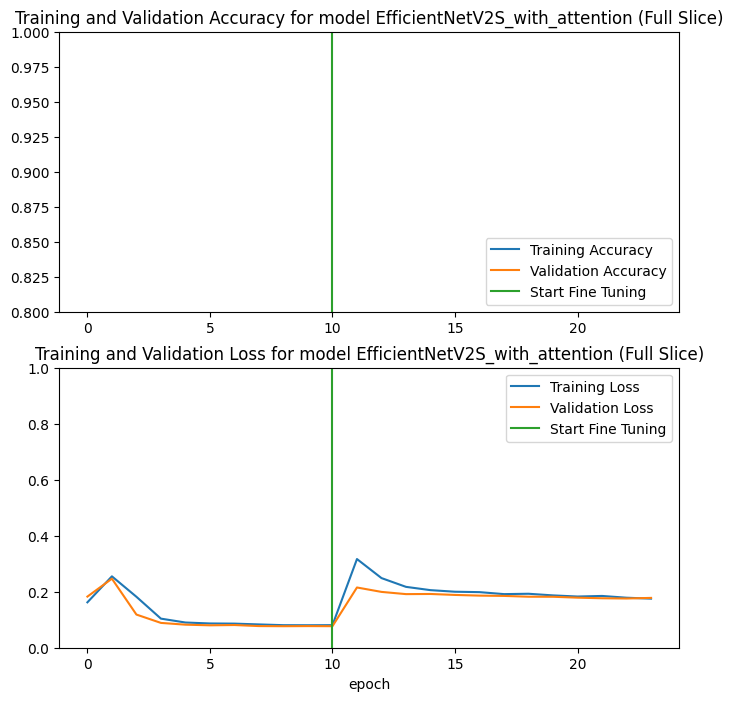

In [97]:
plot_training_val_accuracy(history_transfer_f, history_fine_f, initial_epochs_f, f"{model_name} (Full Slice)")
#plot_training_val_accuracy(history_transfer_n, history_fine_n, initial_epochs_n, f"{model_name} (Nodule)")

In [98]:
model.save(f'{model_name}_binary_full_slice_withFourierAug_weights.keras')
del model

# 🛠️ Build the model: MobileNetV2

In [99]:
tf.keras.mixed_precision.set_global_policy('mixed_float16')

weight_decay = 1e-4

optimizer = tfk.optimizers.Lion(
    learning_rate=learning_rate, #start transfer learning with "high" lr 0.001
    weight_decay=weight_decay,
    clipnorm=1.0,
    )

# Define the base model to fine tune
model_name = "MobileNetV2"
model_to_fine_tune = tfk.applications.MobileNetV2(weights="imagenet",
                          input_shape=input_shape,
                          include_top=False)

preprocessing_mobilenet = tfk.applications.mobilenet_v2.preprocess_input

base_model, model = build_model(optimizer=optimizer, learning_rate=learning_rate,
                                base_model = model_to_fine_tune,
                                preprocessing=preprocessing_mobilenet, loss_fn=loss_fn)

model.summary()
print(f"Number of layers in {model_name} are {len(base_model.layers)}")

(None, 1280)
(None, 128)


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)           │ (None, 256, 256, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ true_divide (TrueDivide)             │ (None, 256, 256, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ subtract (Subtract)                  │ (None, 256, 256, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ mobilenetv2_1.00_224 (Functional)    │ (None, 8, 8, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_3           │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ group_normalization_4                │ (None, 1280)                │           2,560 │
│ (GroupNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 1280)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 128)                 │         163,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gelu_2 (Gelu)                        │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ group_normalization_5                │ (None, 128)                 │             256 │
│ (GroupNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,424,897 (9.25 MB)

 Trainable params: 166,913 (652.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Number of layers in MobileNetV2 are 154


## 🛠️ Train and save the model

In [100]:
# This includes transfer learning + fine tuning
# Train on Full Slice
print("\nTraining on Full Slice Data...")
history_transfer_f, history_fine_f, initial_epochs_f = train_model(
    model,
    X_train_f,  # Nodule training data
    y_train_f,  # Nodule training labels
    X_val_f,    # Nodule validation data
    y_val_f,    # Nodule validation labels
    epochs=epochs,
    batch_size=batch_size,
    class_weight_dict=class_weight_dict,  # Ensure weights are for this dataset
    fine_tune_at=-30,  # Adjust fine-tuning start layer if needed
    loss_fn=loss_fn
)



Training on Full Slice Data...
Epoch 1/1000
119/119 ━━━━━━━━━━━━━━━━━━━━ 31s 146ms/step - accuracy: 0.6819 - loss: 0.1691 - val_accuracy: 0.7585 - val_loss: 0.1849 - learning_rate: 0.0010
Epoch 2/1000
119/119 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.7546 - loss: 0.2352 - val_accuracy: 0.7585 - val_loss: 0.2286 - learning_rate: 0.0010
Epoch 3/1000
119/119 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.7516 - loss: 0.1997 - val_accuracy: 0.7585 - val_loss: 0.1150 - learning_rate: 0.0010
Epoch 4/1000
119/119 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.7520 - loss: 0.1120 - val_accuracy: 0.7585 - val_loss: 0.0907 - learning_rate: 0.0010
Epoch 5/1000
119/119 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.7521 - loss: 0.0937 - val_accuracy: 0.7585 - val_loss: 0.0851 - learning_rate: 0.0010
Epoch 6/1000
119/119 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.7512 - loss: 0.0911 - val_accuracy: 0.7585 - val_loss: 0.0867 - learning_rate: 0.0010
Epoch 7/1000
119/119 ━━━━━━━━━━━━━━━

In [101]:
'''
# Train on Nodule
print("\nTraining on Nodule Data...")
history_transfer_n, history_fine_n, initial_epochs_n = train_model(
    model,
    X_train_n,  # Nodule training data
    y_train_n,  # Nodule training labels
    X_val_n,    # Nodule validation data
    y_val_n,    # Nodule validation labels
    epochs=epochs,
    batch_size=batch_size,
    class_weight_dict=class_weight_dict,  # Ensure weights are for this dataset
    fine_tune_at=0  # Adjust fine-tuning start layer if needed
)
'''

'\n# Train on Nodule\nprint("\nTraining on Nodule Data...")\nhistory_transfer_n, history_fine_n, initial_epochs_n = train_model(\n    model,\n    X_train_n,  # Nodule training data\n    y_train_n,  # Nodule training labels\n    X_val_n,    # Nodule validation data\n    y_val_n,    # Nodule validation labels\n    epochs=epochs,\n    batch_size=batch_size,\n    class_weight_dict=class_weight_dict,  # Ensure weights are for this dataset\n    fine_tune_at=0  # Adjust fine-tuning start layer if needed\n)\n'

In [102]:
# Evaluate Full Slice Model
print("\nEvaluating Full Slice Model...")
test_acc_f, test_pre_f, test_rec_f, test_auc_f, test_conf_f = evaluate_model_with_confidence(
    model, X_test_f, y_test_f
)
model_acc["Full Slice"][model_name] = test_acc_f
model_pre["Full Slice"][model_name] = test_pre_f
model_rec["Full Slice"][model_name] = test_rec_f
model_auc["Full Slice"][model_name] = test_auc_f
model_conf["Full Slice"][model_name] = test_conf_f
'''
# Evaluate Nodule Model
print("\nEvaluating Nodule Model...")
test_acc_n, test_pre_n, test_rec_n, test_auc_n, test_conf_n = evaluate_model_with_confidence(
    model, X_test_n, y_test_n
)
model_acc["Nodule"][model_name] = test_acc_n
model_pre["Nodule"][model_name] = test_pre_n
model_rec["Nodule"][model_name] = test_rec_n
model_auc["Nodule"][model_name] = test_auc_n
model_conf["Nodule"][model_name] = test_conf_n
'''
# Print results for both models
print("\nModel Evaluation Metrics:")
print("Full Slice Model:")
print(
    f"Accuracy: {test_acc_f:.4f}, Precision: {test_pre_f:.4f}, Recall: {test_rec_f:.4f}, AUC: {test_auc_f:.4f}, Confidence: {test_conf_f:.4f}"
)
'''
print("\nNodule Model:")
print(
    f"Accuracy: {test_acc_n:.4f}, Precision: {test_pre_n:.4f}, Recall: {test_rec_n:.4f}, AUC: {test_auc_n:.4f}, Confidence: {test_conf_n:.4f}"
)
'''


Evaluating Full Slice Model...
8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 499ms/step
Test Loss: 0.1841
Test Accuracy: 0.7595
Precision (weighted): 0.5768
Recall (weighted): 0.7595
ROC AUC (weighted): 0.5884
Average Confidence: 0.3191

Model Evaluation Metrics:
Full Slice Model:
Accuracy: 0.7595, Precision: 0.5768, Recall: 0.7595, AUC: 0.5884, Confidence: 0.3191


'\nprint("\nNodule Model:")\nprint(\n    f"Accuracy: {test_acc_n:.4f}, Precision: {test_pre_n:.4f}, Recall: {test_rec_n:.4f}, AUC: {test_auc_n:.4f}, Confidence: {test_conf_n:.4f}"\n)\n'


Confusion Matrix for Full Slice Model:
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


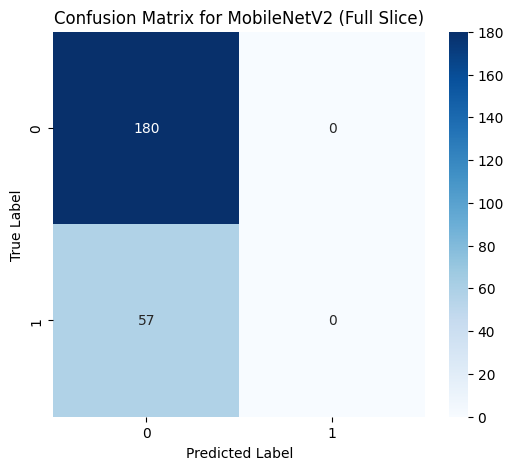

'\n# Plot confusion matrix for Nodule Model\nprint("\nConfusion Matrix for Nodule Model:")\nplot_confusion_matrix(model, X_test_n, y_test_n, f"{model_name} (Nodule)")\n'

In [103]:
# Plot confusion matrix for Full Slice Model
print("\nConfusion Matrix for Full Slice Model:")
plot_confusion_matrix(model, X_test_f, y_test_f, f"{model_name} (Full Slice)")
'''
# Plot confusion matrix for Nodule Model
print("\nConfusion Matrix for Nodule Model:")
plot_confusion_matrix(model, X_test_n, y_test_n, f"{model_name} (Nodule)")
'''

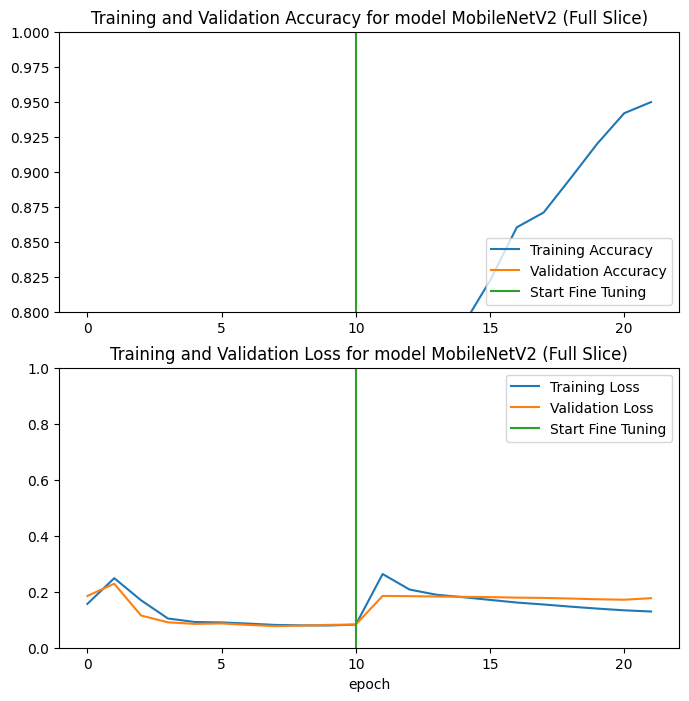

In [104]:
plot_training_val_accuracy(history_transfer_f, history_fine_f, initial_epochs_f, f"{model_name} (Full Slice)")
#plot_training_val_accuracy(history_transfer_n, history_fine_n, initial_epochs_n, f"{model_name} (Nodule)")

In [105]:
model.save(f'{model_name}_binary_full_slice_withFourierAug_weights.keras')
del model

# 🛠️ Build the model: DenseNet121

In [106]:
weight_decay = 1e-4
optimizer = tfk.optimizers.Lion(
    learning_rate=learning_rate, #start transfer learning with "high" lr 0.001
    weight_decay=weight_decay,
    clipnorm=1.0,
    )

# Define the base model to fine tune
model_name = "DenseNet121"
model_to_fine_tune = tfk.applications.DenseNet121(weights="imagenet",
                          input_shape=input_shape,
                          include_top=False)

preprocessing_densenet = tfk.applications.densenet.preprocess_input

base_model, model = build_model(optimizer=optimizer, learning_rate=learning_rate,
                                base_model = model_to_fine_tune,
                                preprocessing=preprocessing_densenet, loss_fn=loss_fn)

model.summary()
print(f"Number of layers in {model_name} are {len(base_model.layers)}")

(None, 1024)
(None, 128)


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)           │ (None, 256, 256, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ true_divide_1 (TrueDivide)           │ (None, 256, 256, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ add (Add)                            │ (None, 256, 256, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ true_divide_2 (TrueDivide)           │ (None, 256, 256, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ densenet121 (Functional)             │ (None, 8, 8, 1024)          │       7,037,504 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_4           │ (None, 1024)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ group_normalization_6                │ (None, 1024)                │           2,048 │
│ (GroupNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 1024)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 128)                 │         131,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gelu_3 (Gelu)                        │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ group_normalization_7                │ (None, 128)                 │             256 │
│ (GroupNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_7 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 7,171,137 (27.36 MB)

 Trainable params: 133,633 (522.00 KB)

 Non-trainable params: 7,037,504 (26.85 MB)

Number of layers in DenseNet121 are 427


In [107]:
# This includes transfer learning + fine tuning
# Train on Full Slice
print("\nTraining on Full Slice Data...")
history_transfer_f, history_fine_f, initial_epochs_f = train_model(
    model,
    X_train_f,  # Nodule training data
    y_train_f,  # Nodule training labels
    X_val_f,    # Nodule validation data
    y_val_f,    # Nodule validation labels
    epochs=epochs,
    batch_size=batch_size,
    class_weight_dict=class_weight_dict,  # Ensure weights are for this dataset
    fine_tune_at=-30,  # Adjust fine-tuning start layer if needed
    loss_fn=loss_fn
)


Training on Full Slice Data...
Epoch 1/1000
119/119 ━━━━━━━━━━━━━━━━━━━━ 73s 340ms/step - accuracy: 0.6858 - loss: 0.1648 - val_accuracy: 0.7585 - val_loss: 0.1440 - learning_rate: 0.0010
Epoch 2/1000
119/119 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - accuracy: 0.7476 - loss: 0.1675 - val_accuracy: 0.7585 - val_loss: 0.1364 - learning_rate: 0.0010
Epoch 3/1000
119/119 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - accuracy: 0.7521 - loss: 0.1259 - val_accuracy: 0.7585 - val_loss: 0.0811 - learning_rate: 0.0010
Epoch 4/1000
119/119 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - accuracy: 0.7512 - loss: 0.0827 - val_accuracy: 0.7585 - val_loss: 0.0680 - learning_rate: 0.0010
Epoch 5/1000
119/119 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - accuracy: 0.7521 - loss: 0.0720 - val_accuracy: 0.7585 - val_loss: 0.0639 - learning_rate: 0.0010
Epoch 6/1000
119/119 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - accuracy: 0.7521 - loss: 0.0706 - val_accuracy: 0.7585 - val_loss: 0.0653 - learning_rate: 0.0010
Epoch 7/1000
119/119 ━━━━━━━━━━━━━━━

In [108]:
'''
# Train on Nodule
print("\nTraining on Nodule Data...")
history_transfer_n, history_fine_n, initial_epochs_n = train_model(
    model,
    X_train_n,  # Nodule training data
    y_train_n,  # Nodule training labels
    X_val_n,    # Nodule validation data
    y_val_n,    # Nodule validation labels
    epochs=epochs,
    batch_size=batch_size,
    class_weight_dict=class_weight_dict,  # Ensure weights are for this dataset
    fine_tune_at=0  # Adjust fine-tuning start layer if needed
)
'''

'\n# Train on Nodule\nprint("\nTraining on Nodule Data...")\nhistory_transfer_n, history_fine_n, initial_epochs_n = train_model(\n    model,\n    X_train_n,  # Nodule training data\n    y_train_n,  # Nodule training labels\n    X_val_n,    # Nodule validation data\n    y_val_n,    # Nodule validation labels\n    epochs=epochs,\n    batch_size=batch_size,\n    class_weight_dict=class_weight_dict,  # Ensure weights are for this dataset\n    fine_tune_at=0  # Adjust fine-tuning start layer if needed\n)\n'

In [109]:
# Evaluate Full Slice Model
print("\nEvaluating Full Slice Model...")
test_acc_f, test_pre_f, test_rec_f, test_auc_f, test_conf_f = evaluate_model_with_confidence(
    model, X_test_f, y_test_f
)
model_acc["Full Slice"][model_name] = test_acc_f
model_pre["Full Slice"][model_name] = test_pre_f
model_rec["Full Slice"][model_name] = test_rec_f
model_auc["Full Slice"][model_name] = test_auc_f
model_conf["Full Slice"][model_name] = test_conf_f
'''
# Evaluate Nodule Model
print("\nEvaluating Nodule Model...")
test_acc_n, test_pre_n, test_rec_n, test_auc_n, test_conf_n = evaluate_model_with_confidence(
    model, X_test_n, y_test_n
)
model_acc["Nodule"][model_name] = test_acc_n
model_pre["Nodule"][model_name] = test_pre_n
model_rec["Nodule"][model_name] = test_rec_n
model_auc["Nodule"][model_name] = test_auc_n
model_conf["Nodule"][model_name] = test_conf_n
'''
# Print results for both models
print("\nModel Evaluation Metrics:")
print("Full Slice Model:")
print(
    f"Accuracy: {test_acc_f:.4f}, Precision: {test_pre_f:.4f}, Recall: {test_rec_f:.4f}, AUC: {test_auc_f:.4f}, Confidence: {test_conf_f:.4f}"
)

'''
print("\nNodule Model:")
print(
    f"Accuracy: {test_acc_n:.4f}, Precision: {test_pre_n:.4f}, Recall: {test_rec_n:.4f}, AUC: {test_auc_n:.4f}, Confidence: {test_conf_n:.4f}"
)
'''


Evaluating Full Slice Model...
8/8 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step
Test Loss: 0.1408
Test Accuracy: 0.7595
Precision (weighted): 0.5768
Recall (weighted): 0.7595
ROC AUC (weighted): 0.6401
Average Confidence: 0.2766

Model Evaluation Metrics:
Full Slice Model:
Accuracy: 0.7595, Precision: 0.5768, Recall: 0.7595, AUC: 0.6401, Confidence: 0.2766


'\nprint("\nNodule Model:")\nprint(\n    f"Accuracy: {test_acc_n:.4f}, Precision: {test_pre_n:.4f}, Recall: {test_rec_n:.4f}, AUC: {test_auc_n:.4f}, Confidence: {test_conf_n:.4f}"\n)\n'


Confusion Matrix for Full Slice Model:
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


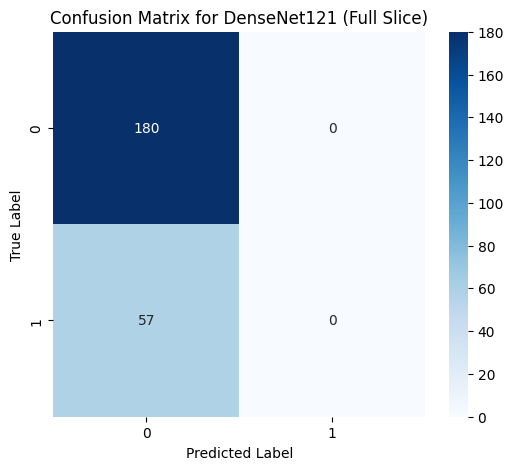

'\n# Plot confusion matrix for Nodule Model\nprint("\nConfusion Matrix for Nodule Model:")\nplot_confusion_matrix(model, X_test_n, y_test_n, f"{model_name} (Nodule)")\n'

In [110]:
# Plot confusion matrix for Full Slice Model
print("\nConfusion Matrix for Full Slice Model:")
plot_confusion_matrix(model, X_test_f, y_test_f, f"{model_name} (Full Slice)")
'''
# Plot confusion matrix for Nodule Model
print("\nConfusion Matrix for Nodule Model:")
plot_confusion_matrix(model, X_test_n, y_test_n, f"{model_name} (Nodule)")
'''

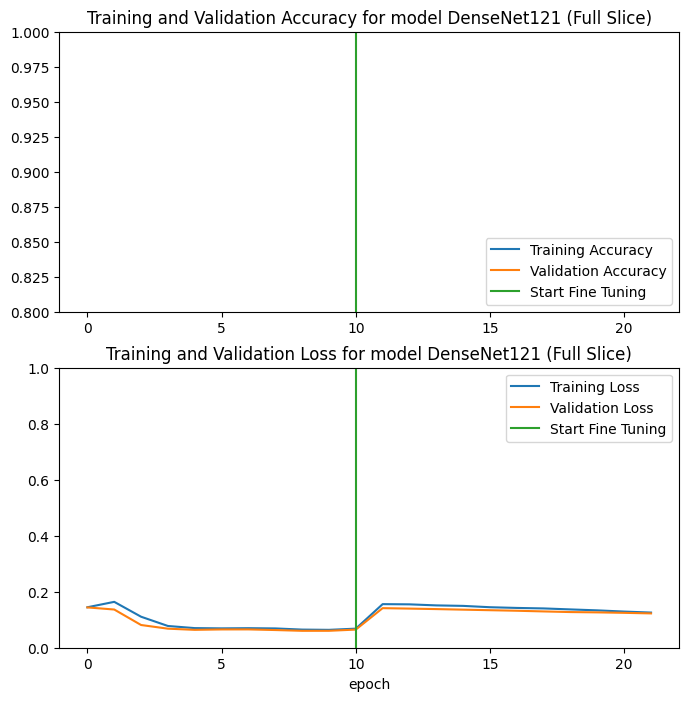

In [111]:
plot_training_val_accuracy(history_transfer_f, history_fine_f, initial_epochs_f, f"{model_name} (Full Slice)")
#plot_training_val_accuracy(history_transfer_n, history_fine_n, initial_epochs_n, f"{model_name} (Nodule)")

In [112]:
model.save(f'{model_name}_binary_full_slice_withFourierAug_weights.keras')
del model